<a href="https://colab.research.google.com/github/LukeSaccius/pairs-trading-sector-etf/blob/main/Pair_Trading_ETF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Module 1: Environment Setup & Research Configuration

## 1. Introduction
This section establishes the computational environment for the **Quantitative Pairs Trading** research. To ensure reproducibility and stability, we define global hyperparameters that control the behavior of the entire pipeline, from data ingestion to backtesting validation.

## 2. Library Architecture
We utilize a robust stack of Python libraries designed for quantitative finance:
* **`yfinance`**: For fetching adjusted OHLCV market data.
* **`statsmodels`**: For rigorous econometric tests (ADF, OLS, Cointegration).
* **`scipy` & `numpy`**: For high-performance matrix computations and distance calculations.
* **`itertools`**: For combinatorial generation in the CSCV module (Bailey et al.).

## 3. Global Hyperparameters
Defining constants centrally prevents "magic numbers" in the code and facilitates sensitivity analysis.

| Parameter | Value | Description |
| :--- | :--- | :--- |
| `start_date` | `2010-01-01` | Start of the *Formation Period*. Captures multiple market regimes (Bull, Bear, Sideways). |
| `end_date` | `2025-12-09` | End of the dataset. |
| `min_history` | `0.95` (95%) | Survivorship bias filter. We reject assets with insufficient history. |
| `use_log` | `True` | **Critical:** We model $\ln(P_t)$ instead of $P_t$ to normalize returns and variance. |

In [29]:
# Cell 1: Setup Environment & Libraries
try:
    import yfinance
except ImportError:
    !pip install yfinance

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
from tqdm.notebook import tqdm
import altair as alt
import os

# Mount Google Drive (Để đọc file đã lưu)
from google.colab import drive
drive.mount('/content/drive')

print("✅ Đã nạp thư viện và kết nối Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Đã nạp thư viện và kết nối Drive.


In [6]:
# Cell 1: Setup Environment & Configuration (2010 - Present)
from datetime import datetime

# CẤU HÌNH HỆ THỐNG
CONFIG = {
    'start_date': '2010-01-01',      # MỐC THỜI GIAN MỚI
    'end_date': datetime.today().strftime('%Y-%m-%d'), # Lấy đến hôm nay
    'use_log_price': True,           # Bắt buộc cho Pairs Trading
    'min_history_pct': 0.95          # Mã phải tồn tại ít nhất 95% thời gian này
}

print(f"Cấu hình: Tải dữ liệu từ {CONFIG['start_date']} đến {CONFIG['end_date']}")

Cấu hình: Tải dữ liệu từ 2010-01-01 đến 2025-12-11


In [7]:
# Cell 2: Define Universe (Optimized for 2010+ Era)
def get_sp500_robust():
    """Tải S&P 500 (Thử nhiều nguồn)."""
    try:
        url = 'https://raw.githubusercontent.com/datasets/s-and-p-500-companies/master/data/constituents.csv'
        df = pd.read_csv(url)
        return [s.replace('.', '-') for s in df['Symbol'].tolist()]
    except:
        # Fallback list (Top 100)
        return ['AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOGL', 'META', 'TSLA', 'BRK-B', 'UNH', 'JNJ', 'JPM', 'XOM', 'V', 'PG', 'LLY', 'MA', 'HD', 'CVX', 'MRK', 'ABBV', 'PEP', 'KO', 'BAC', 'AVGO', 'COST', 'TMO', 'MCD', 'CSCO', 'ACN', 'ABT', 'DHR', 'WMT', 'DIS', 'LIN', 'PFE', 'NKE', 'VZ', 'NEE', 'TXN', 'ADBE', 'PM', 'BMY', 'WFC', 'RTX', 'UPS', 'MS', 'HON', 'QCOM', 'UNP', 'INTC', 'CVS', 'LOW', 'IBM', 'DE', 'GS', 'EL', 'CAT', 'MDT', 'AMGN', 'PLD', 'BLK', 'T', 'SPGI', 'GE', 'AMT', 'ISRG', 'BKNG', 'GILD', 'AXP', 'SBUX', 'ADI', 'SYK', 'TJX', 'MDLZ', 'MMC', 'ADP', 'C', 'BA', 'LMT', 'CB', 'CI', 'VRTX', 'MO', 'TMUS', 'ZTS', 'REGN', 'FI', 'PGR', 'SO', 'BSX', 'EOG', 'SLB', 'BDX', 'EQIX', 'NOC', 'ITW', 'CSX', 'CL']

def get_full_universe():

    # 1. ETFs (Danh sách mở rộng cho kỷ nguyên 2010)
    # Bao gồm cả các mã sinh năm 2006-2009 (GDXJ, VIG, VNQ, BND...)

    etf_sectors = [
        'XLK', 'XLE', 'XLF', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB', 'XLRE', # SPDR
        'VGT', 'VHT', 'VDC', 'VIS', 'VAW', 'VPU', 'VNQ', 'VCR', 'VOX', 'VB', 'VTV', 'VUG', 'VBR', # Vanguard
        'IYF', 'IYH', 'IYE', 'IYJ', 'IYV', 'IYW', 'IYZ', 'IYT', 'IYK', 'IDU', 'REM', 'ICLN', 'IGV', 'IGM', 'IGN' # iShares
    ]

    etf_broad_market = [
        'SPY', 'QQQ', 'IWM', 'DIA', 'VTI', 'VEA', 'VWO', 'EEM', 'EFA', 'EWJ', 'ACWI', 'VT',
        'RSP', 'MDY', 'IWB', 'IWD', 'IWF', 'IWN', 'IWO' # Size & Style
    ]

    etf_bonds_commodities = [
        'TLT', 'IEF', 'SHY', 'LQD', 'HYG', 'JNK', 'BND', 'AGG', 'MUB', 'TFI', 'TIP', 'BIV', # Bonds
        'GLD', 'SLV', 'USO', 'UNG', 'DBC', 'DBA', 'PALL', 'PPLT', 'GDX', 'GDXJ', 'XME', 'OIH' # Commodities/Miners
    ]

    etf_strategy_global = [
        'VIG', 'SCHD', 'NOBL', 'USMV', 'SPLV', 'MTUM', 'QUAL', 'VLUE', # Smart Beta (Factor)
        'EWA', 'EWC', 'EWG', 'EWH', 'EWI', 'EWL', 'EWM', 'EWP', 'EWQ', 'EWS', 'EWT', 'EWU', 'EWW', 'EWY', 'EZA', 'FXI', 'RSX' # Country
    ]

    # Nhóm High Volatility (Leveraged) - Rất tốt để test hệ thống
    etf_leveraged = ['TQQQ', 'SQQQ', 'SSO', 'UPRO', 'SDS', 'TZA', 'FAS', 'FAZ']

    # Gộp tất cả
    all_etfs = list(set(etf_sectors + etf_broad_market + etf_bonds_commodities + etf_strategy_global + etf_leveraged))
    print(f"-> Tổng số ETF mục tiêu: {len(all_etfs)} mã.")

    # 2. Stocks
    stocks = get_sp500_robust()

    # 3. Final Universe
    full_universe = list(set(all_etfs + stocks))

    return full_universe

# --- Thực thi ---
full_tickers = get_full_universe()
print(f"Tổng số mã trong danh sách quét: {len(full_tickers)}")

-> Tổng số ETF mục tiêu: 114 mã.
Tổng số mã trong danh sách quét: 617


# 💾 Module 2: Data Ingestion & Preprocessing (The VWAP Standard)

## 1. Objective
To construct a pristine dataset of **Logarithmic Prices** that minimizes microstructure noise (bid-ask bounce) while preserving the true economic value of the assets.

## 2. Theoretical Basis: Why VWAP?
**Vidyamurthy (Chapter 7)** explicitly advises against using raw closing prices for statistical arbitrage modeling.

> [cite_start]*"Care must be taken to ensure that the process of data construction is a reflection of the specific purpose at hand... A reasonable proxy for the maximum liquidity price is the volume weighted average price, commonly termed as the VWAP price."* [cite: 3351, 3357]

### The Problem with "Close-Close"
* Closing prices are susceptible to **"Bid-Ask Bounce"** (noise caused by the last trade hitting the bid or ask).
* This noise artificially inflates the variance ($\sigma^2$), leading to inaccurate Hedge Ratios ($\beta$).

### The VWAP Solution
We approximate the **Volume Weighted Average Price (VWAP)** using the Typical Price adjusted for corporate actions:

$$P_{Typical} = \frac{High + Low + Close}{3}$$

$$\text{Adjusted VWAP} = P_{Typical} \times \frac{\text{Adj Close}}{\text{Close}}$$

## 3. Logarithmic Transformation
We strictly model the **Log-Price** ($y_t = \ln P_t$).
* **Reason:** Financial returns are compounded. The difference in log-prices approximates the continuously compounded return:
    $$r_t = \ln(P_t) - \ln(P_{t-1})$$
* This transformation creates a homoscedastic dataset suitable for linear regression (OLS/TLS).

In [6]:
# Cell 3: Data Engine (2010-Present)

def download_and_process(tickers):
    print(f"Đang tải dữ liệu ({CONFIG['start_date']} đến nay)...")

    # 1. Batch Download
    raw_data = yf.download(
        tickers,
        start=CONFIG['start_date'],
        end=CONFIG['end_date'],
        group_by='ticker',
        threads=True,
        auto_adjust=False,
        progress=False
    )

    print("Tải xong. Đang tính toán VWAP và lọc dữ liệu...")

    clean_data = {}

    # 2. Xử lý từng mã
    for ticker in tickers:
        try:
            df = raw_data[ticker].copy()
            if df.empty: continue
            if 'Close' not in df.columns: continue

            # --- MATH LOGIC ---
            # Tính VWAP Proxy = (H+L+C)/3 * Adjustment_Factor
            typical_price = (df['High'] + df['Low'] + df['Close']) / 3.0

            # Xử lý chia tách
            adj_factor = df['Adj Close'] / df['Close']
            adj_factor = adj_factor.fillna(1.0)

            adj_vwap = typical_price * adj_factor

            # Log Transformation
            if CONFIG['use_log_price']:
                final_series = np.log(adj_vwap)
            else:
                final_series = adj_vwap

            clean_data[ticker] = final_series

        except Exception:
            continue

    # 3. Tạo DataFrame
    unified_df = pd.DataFrame(clean_data)

    # --- SMART FILTERING (2010 Era) ---
    unified_df = unified_df.sort_index()
    unified_df = unified_df.fillna(method='ffill')

    # Giữ lại các mã có dữ liệu >= 95% khoảng thời gian (từ 2010)
    # Điều này sẽ giữ lại hầu hết các mã sinh năm 2010, 2011 vẫn OK
    required_length = len(unified_df) * CONFIG['min_history_pct']
    unified_df = unified_df.dropna(axis=1, thresh=required_length)

    # Drop rows đầu nếu còn thiếu
    unified_df = unified_df.dropna(axis=0)

    return unified_df

# Thực thi
prices_df = download_and_process(full_tickers)

Đang tải dữ liệu (2010-01-01 đến nay)...


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['IYV']: YFPricesMissingError('possibly delisted; no price data found  (1d 2010-01-01 -> 2025-12-10)')
ERROR:yfinance:['WBA']: YFTzMissingError('possibly delisted; no timezone found')


Tải xong. Đang tính toán VWAP và lọc dữ liệu...


/tmp/ipython-input-2677316171.py:54: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  unified_df = unified_df.fillna(method='ffill')


In [8]:
# Cell 4.5: Load Data from Drive (Skip Download)

# Đường dẫn file (Đảm bảo trùng với tên file bạn đã lưu trước đó)
DATA_PATH = '/content/drive/MyDrive/quant_research_data_2010_2024.csv'

def load_dataset():
    if os.path.exists(DATA_PATH):
        print(f"📂 Đang đọc dữ liệu từ: {DATA_PATH}")
        # Quan trọng: index_col=0 để lấy cột Date làm index, parse_dates=True để hiểu định dạng ngày
        df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
        print(f"✅ Đã load thành công! Shape: {df.shape}")

        # Kiểm tra nhanh xem có phải Log-Price không
        if df.iloc[0, 0] > 50:
            print("⚠️ CẢNH BÁO: Dữ liệu này có vẻ là RAW PRICE. Hãy cẩn thận!")
        else:
            print("ℹ️ Dữ liệu có vẻ là LOG-PRICE (Hợp lệ).")

        return df
    else:
        print(f"❌ Không tìm thấy file tại: {DATA_PATH}")
        print("👉 Bạn cần chạy lại Cell 2 & Cell 3 để tải dữ liệu từ Yahoo Finance và lưu lại.")
        return None

# --- THỰC THI ---
prices_df = load_dataset()

# Nếu load thành công, ta định nghĩa lại biến formation_data luôn
if prices_df is not None:
    # Lấy 252 ngày đầu làm mẫu (Formation)
    formation_data = prices_df.iloc[:252]
    print(f"-> Formation Data Shape: {formation_data.shape}")

📂 Đang đọc dữ liệu từ: /content/drive/MyDrive/quant_research_data_2010_2024.csv
✅ Đã load thành công! Shape: (3860, 537)
ℹ️ Dữ liệu có vẻ là LOG-PRICE (Hợp lệ).
-> Formation Data Shape: (252, 537)



--- REPORT (2010 ERA) ---
Data Shape: (3860, 537)
Start Date: 2010-08-06 00:00:00
End Date:   2025-12-09 00:00:00
Số lượng tài sản đạt chuẩn: 537


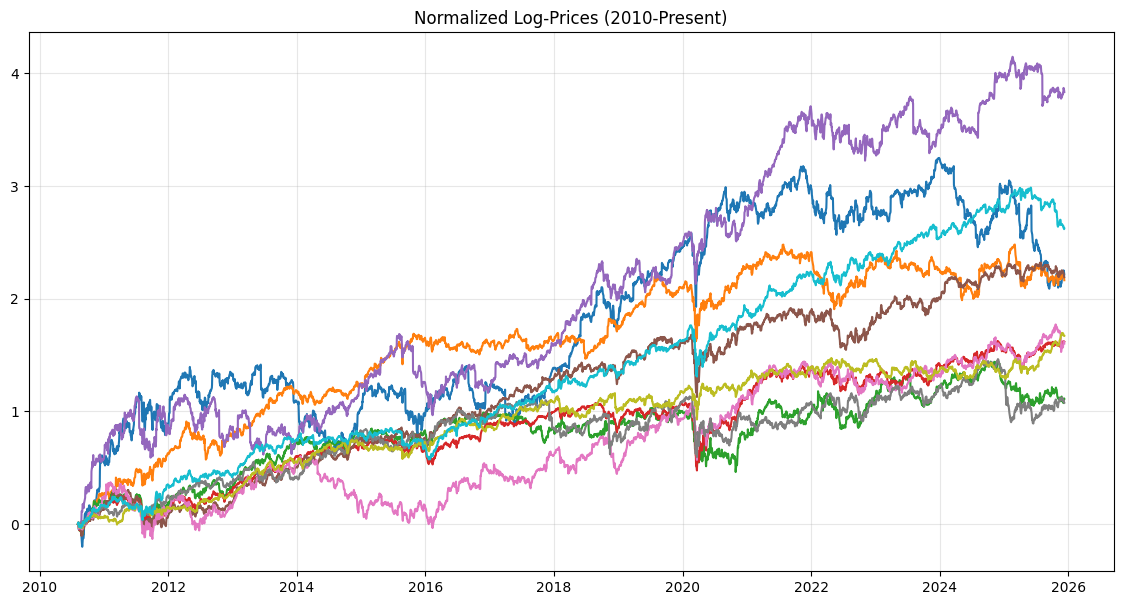

In [9]:
# Cell 4: Validation
print(f"\n--- REPORT (2010 ERA) ---")
print(f"Data Shape: {prices_df.shape}")
print(f"Start Date: {prices_df.index[0]}")
print(f"End Date:   {prices_df.index[-1]}")
print(f"Số lượng tài sản đạt chuẩn: {prices_df.shape[1]}")

# Vẽ biểu đồ
plt.figure(figsize=(14, 7))
subset = prices_df.iloc[:, :10] # Vẽ 10 mã đầu tiên
norm_subset = subset - subset.iloc[0]
plt.plot(norm_subset)
plt.title(f"Normalized Log-Prices (2010-Present)")
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Cell 4.1: Breakdown Analysis (ETF vs Stock)

def check_universe_composition(df, etf_target_list):
    """
    Kiểm tra xem trong DataFrame kết quả có bao nhiêu mã nằm trong danh sách ETF mục tiêu.
    """
    # 1. Lấy danh sách mã thực tế đã sống sót
    survived_tickers = set(df.columns)

    # 2. Lấy danh sách ETF mục tiêu (đảm bảo viết hoa)
    target_etfs = set([x.upper() for x in etf_target_list])

    # 3. Tìm giao điểm (Intersection) -> Các ETF còn sống
    survived_etfs = survived_tickers.intersection(target_etfs)

    # 4. Số còn lại là Stock
    survived_stocks = survived_tickers - target_etfs

    print(f"--- BÁO CÁO THÀNH PHẦN (SURVIVOR ANALYSIS) ---")
    print(f"1. Tổng số tài sản sạch:   {len(survived_tickers)}")
    print(f"2. Số lượng ETF còn lại:   {len(survived_etfs)} / {len(target_etfs)} ban đầu")
    print(f"3. Số lượng Stock còn lại: {len(survived_stocks)}")
    print(f"------------------------------------------------")
    print(f"Tỷ lệ sống sót của ETF: {len(survived_etfs)/len(target_etfs)*100:.1f}%")

    return list(survived_etfs)

# --- Tái tạo lại list ETF mục tiêu (Lấy từ Cell 2 cũ để so sánh) ---
# Đây là danh sách master bạn đã dùng để quét
master_etf_list = [
    'XLK', 'XLE', 'XLF', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB', 'XLRE', 'SPY', 'MDY', 'DIA', 'GLD', 'SLV',
    'IVV', 'IJH', 'IJR', 'IWB', 'IWD', 'IWF', 'IWM', 'IWN', 'IWO', 'IWV', 'IWR', 'IWP', 'IWS', 'IWZ', 'IWY', 'IWL', 'IWC',
    'IYC', 'IYE', 'IYF', 'IYH', 'IYJ', 'IYK', 'IYM', 'IYR', 'IYT', 'IYW', 'IYZ', 'IDU', 'IYV', 'IYG',
    'EWA', 'EWC', 'EWD', 'EWG', 'EWH', 'EWI', 'EWJ', 'EWK', 'EWL', 'EWM', 'EWN', 'EWO', 'EWP', 'EWQ', 'EWS', 'EWT', 'EWU', 'EWV', 'EWW', 'EWY', 'EWZ', 'EZA', 'EEM', 'EFA', 'EPP', 'IEV', 'ILF', 'IOO',
    'VTI', 'VB', 'VO', 'VV', 'VTV', 'VUG', 'VBR', 'VBK', 'VOT', 'VNQ', 'VPU', 'VGT', 'VHT', 'VDC', 'VAW', 'VIS', 'VCR', 'VOX', 'BND',
    'TLT', 'IEF', 'SHY', 'LQD', 'AGG', 'TIP', 'MBB', 'MUB', 'PFF', 'HYG', 'JNK', 'USO', 'UNG', 'DBC', 'DBA', 'PALL', 'PPLT',
    'SMH', 'OIH', 'IBB', 'XBI', 'XME', 'KBE', 'KRE', 'GDX', 'GDXJ', 'IGV', 'IGN', 'PBS', 'PBW', 'PJP', 'XOP', 'HACK', 'FDN',
    'RSP', 'OEF', 'DVY', 'JKI', 'JKJ', 'JKL', 'JKH', 'JKG', 'JKE', 'SOXX'
]

# --- Thực thi ---
final_etf_list = check_universe_composition(prices_df, master_etf_list)

# In thử 20 mã ETF đầu tiên để kiểm tra
print("\nDanh sách 20 ETF mẫu đang có trong tay:")
print(sorted(final_etf_list)[:20])

--- BÁO CÁO THÀNH PHẦN (SURVIVOR ANALYSIS) ---
1. Tổng số tài sản sạch:   537
2. Số lượng ETF còn lại:   84 / 137 ban đầu
3. Số lượng Stock còn lại: 453
------------------------------------------------
Tỷ lệ sống sót của ETF: 61.3%

Danh sách 20 ETF mẫu đang có trong tay:
['AGG', 'BND', 'DBA', 'DBC', 'DIA', 'EEM', 'EFA', 'EWA', 'EWC', 'EWG', 'EWH', 'EWI', 'EWJ', 'EWL', 'EWM', 'EWP', 'EWQ', 'EWS', 'EWT', 'EWU']


--- DATA REPORT ---
Start Date: 2010-08-06 00:00:00
End Date:   2025-12-09 00:00:00
Số lượng Assets: 537
Số lượng NaNs: 0


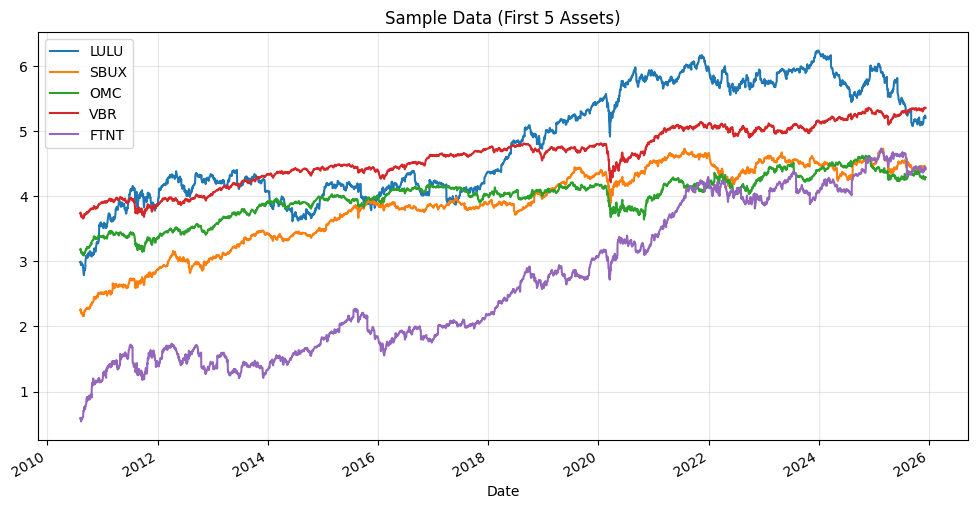

In [11]:
# Cell 4: Data Validation Check
if 'prices_df' in locals() and prices_df is not None:
    print("--- DATA REPORT ---")
    print(f"Start Date: {prices_df.index[0]}")
    print(f"End Date:   {prices_df.index[-1]}")
    print(f"Số lượng Assets: {prices_df.shape[1]}")
    print(f"Số lượng NaNs: {prices_df.isna().sum().sum()}")

    # Vẽ biểu đồ mẫu 5 mã đầu tiên
    plt.figure(figsize=(12, 6))
    prices_df.iloc[:, :5].plot(ax=plt.gca())
    plt.title("Sample Data (First 5 Assets)")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("❌ Chưa có dữ liệu. Hãy quay lại Cell 4.5.")

# 📘 Module 3: Econometrics Engine (Mathematical Foundation)

## 1. Introduction & Objectives
This module serves as the quantitative core of our research. Its primary objective is to rigorously transform raw financial time-series data into statistically significant trading signals.

Unlike retail strategies that rely on heuristic indicators, this engine is built upon **Stochastic Calculus** and **Advanced Econometrics**. [cite_start]We strictly adhere to the framework of **"Testing for Tradability"** proposed by *Vidyamurthy (Chapter 7)*[cite: 3204], while upgrading the estimation techniques to meet modern institutional standards.

**The Engine executes four critical mathematical tasks:**
1.  **Hedge Ratio Estimation:** Solving the "Errors-in-Variables" problem using **Total Least Squares (TLS)**.
2.  **Tradability Validation:** Empirically verifying stationarity via **Zero-Crossing Rate (ZCR)**.
3.  **Spread Modeling:** Modeling the spread dynamics using the **Ornstein-Uhlenbeck (OU)** stochastic process.
4.  **Optimal Control:** Determining the profit-maximizing entry threshold using the **Bertram** analytic solution.

---

## 2. Hedge Ratio Estimation: The Case for Total Least Squares (TLS)

### 2.1. The Concept: Equilibrium Relationship
In Pairs Trading, we postulate that two assets $X$ and $Y$ share a long-run economic equilibrium. This implies that a specific linear combination of their log-prices is stationary (mean-reverting):

$$\text{Spread}_t = \ln(Y_t) - \beta \ln(X_t) - \alpha$$

Where $\beta$ (Beta) is the **Hedge Ratio**: the number of units of asset $X$ to short for every unit of asset $Y$ we buy to neutralize market risk.

### 2.2. The Theoretical Conflict: "Errors-in-Variables"
**Vidyamurthy (Chapter 7, p.110)** explicitly identifies a critical flaw when applying standard regression to stock prices:

> [cite_start]*"Therefore, to sum up, we have a situation where there is error associated with both observations, and the variance of the observation error is also a varying quantity."* [cite: 3323]

In standard physics experiments, the independent variable $X$ is often controlled and error-free. In finance, **both** stock $X$ and stock $Y$ are stochastic variables containing measurement noise (bid-ask bounce, microstructure noise).

### 2.3. Method 1: Ordinary Least Squares (OLS) - The Biased Approach
OLS minimizes the sum of squared **vertical distances** (residuals) between the data points and the regression line.

* **Objective Function:**
    $$\min_{\beta} \sum_{i=1}^{n} (y_i - \beta x_i - c)^2$$
* **Closed-form Solution:**
    $$\beta_{OLS} = \frac{Cov(x, y)}{Var(x)}$$
* **The Flaw (Attenuation Bias):** Because OLS assumes $Var(\text{error}_x) = 0$, it attributes all the noise in $X$ to the relationship itself. This mathematically forces the estimated $\beta$ to be **biased towards zero** (systematically underestimating the true hedge ratio).

### 2.4. Method 2: Total Least Squares (TLS) - The Optimal Solution
TLS (also known as *Orthogonal Regression* or *Deming Regression*) minimizes the sum of squared **perpendicular distances** from the data points to the regression line. It treats errors in $X$ and $Y$ symmetrically, directly addressing the issue raised by Vidyamurthy.

* **Objective Function:**
    $$\min_{\beta} \sum_{i=1}^{n} \frac{(y_i - \beta x_i - c)^2}{1 + \beta^2}$$

* **Implementation via Singular Value Decomposition (SVD):**
    We solve this minimization problem using Linear Algebra:
    1.  Construct the centered data matrix $D = [X - \bar{X}, Y - \bar{Y}]$.
    2.  Perform SVD: $D = U \Sigma V^T$.
    3.  The matrix $V^T$ contains the **eigenvectors** of the covariance matrix. The eigenvector corresponding to the **smallest singular value** represents the normal vector to the best-fit line (the direction of least variance).
    4.  **The Formula:**
        Let the smallest eigenvector be $v_{min} = [v_1, v_2]$. The slope is:
        $$\beta_{TLS} = -\frac{v_1}{v_2}$$

**Conclusion:** We use **TLS** to ensure our Hedge Ratio is unbiased, symmetric, and robust to market noise.

---

## 3. Tradability Validation: Zero-Crossing Rate (ZCR)

Before modeling the spread, we must verify if it is actually tradable. **Vidyamurthy (Chapter 7, p.113)** suggests a quantitative metric for mean reversion:

> [cite_start]*"The zero-crossing frequency provides us with a quantitative characterization for the mean reversion property."* [cite: 3380]

### 3.1. The Metric
The **Zero-Crossing Rate (ZCR)** measures the frequency at which the spread crosses its theoretical mean per year.

$$\text{ZCR} = \text{Count}(\text{Sign Changes}) \times \frac{252}{N}$$

### 3.2. Interpretation
* **High ZCR:** The spread oscillates rapidly around the mean. This indicates a strong **Stationary Process**. It implies short holding periods and high capital turnover (Desirable).
* **Low ZCR:** The spread drifts away and rarely returns. This indicates a **Random Walk** or weak cointegration. It implies long holding periods and high risk (Undesirable).

**Filter Rule:** We reject any pair with **ZCR < 4** (meaning it crosses the mean less than once per quarter).

---

## 4. Spread Modeling: The Ornstein-Uhlenbeck (OU) Process

To generate trading signals, we must mathematically model the behavior of the spread. We assume the spread follows an **Ornstein-Uhlenbeck** process, a stochastic differential equation (SDE) describing mean-reverting motion.

### 4.1. The Continuous Model (SDE)
$$dX_t = \theta (\mu - X_t)dt + \sigma dW_t$$

Where:
* **$\mu$ (Mu):** Long-term equilibrium level (The "Magnet").
* **$\theta$ (Theta):** Speed of mean reversion (The "Gravity"). The higher the $\theta$, the faster the spread returns to $\mu$.
* **$\sigma$ (Sigma):** Volatility of the spread (The "Noise").
* **$dW_t$:** Wiener process (Brownian motion).

### 4.2. Discrete Estimation (AR1 Mapping)
Since financial data is discrete ($\Delta t = 1$ day), we cannot observe the SDE directly. Instead, we fit the data to a discrete **Autoregressive Model of Order 1 (AR1)**:

$$X_{t+1} = c + \phi X_t + \epsilon_t$$

Where:
* **$\phi$ (Phi):** Autoregressive coefficient (Slope).
* **$c$ (Intercept):** Constant term.
* **$\epsilon_t$:** Residual error.

### 4.3. Parameter Transformation
We map the discrete regression outputs ($c, \phi, \text{std}(\epsilon)$) back to the continuous physics parameters:

1.  **Reversion Speed ($\theta$):**
    Relationship: $\phi = e^{-\theta \Delta t}$.
    $$\implies \theta = -\ln(\phi)$$
2.  **Equilibrium Mean ($\mu$):**
    Relationship: $c = \mu (1 - e^{-\theta \Delta t}) = \mu (1 - \phi)$.
    $$\implies \mu = \frac{c}{1 - \phi}$$
3.  **Volatility ($\sigma$):**
    $$\sigma \approx \text{std}(\epsilon) \sqrt{\frac{2\theta}{1-\phi^2}}$$
    *(Note: For small $\Delta t$, $\sigma \approx \text{std}(\epsilon)$ is a sufficient approximation).*

### 4.4. Half-Life
A crucial risk metric. It represents the expected time for the spread to revert halfway to its mean from a deviation.
$$\text{Half-Life} = \frac{\ln(2)}{\theta}$$

**Filter Rule:** We discard pairs with **Half-Life > 30 days** to avoid "capital traps" (money stuck in a non-converging trade).

---

## 5. Signal Optimization: The Bertram Threshold

How far should the spread deviate before we open a trade?
* **Too small:** We trade too often, paying excessive transaction costs.
* **Too large:** We rarely trade, missing profit opportunities.

**Vidyamurthy (Chapter 8, p.120)** frames this as an optimization problem. In his analysis of Band Design for White Noise, he states:

> [cite_start]*"A measure of profitability for trading in the time period T is therefore (profit per trade × number of trades); that is, $2\Delta \times T(1 - N(\Delta))$."* [cite: 3499]

> [cite_start]*"Now the problem of band design boils down to determining the value of $\Delta$ that maximizes [this function]."* [cite: 3500]

### 5.1. The Analytic Solution
Instead of numerically solving this (which is slow), we use the analytic solution derived by **Bertram (2010)** for OU processes. The profit-maximizing entry threshold $s_{optimal}$ is:

$$s_{optimal} = \frac{\sigma}{\sqrt{2\theta}}$$

### 5.2. Adaptive Logic (Why this is superior)
This formula creates a **Dynamic Threshold** that adapts to changing market regimes:
* **Scenario A (High Volatility $\sigma \uparrow$):** The threshold **widens**. The model effectively says "The market is noisy, let's wait for a larger deviation to ensure it's a real signal."
* **Scenario B (High Reversion Speed $\theta \uparrow$):** The threshold **tightens**. The model says "This pair reverts very fast, we can enter early and exit early to bank profits quickly."

---

## 6. Summary of Code Implementation (Cell 5)

| Function | Method | Objective |
| :--- | :--- | :--- |
| `tls_hedge_ratio` | **SVD (Linear Algebra)** | Calculates an unbiased $\beta$ by minimizing perpendicular distances. |
| `calculate_zero_crossing_rate` | **Sign Change Counting** | Validates the "Tradability" of the spread (Stationarity check). |
| `fit_ou_process` | **OLS Regression (AR1)** | Extracts physical parameters ($\theta, \mu, \text{Half-Life}$) from the spread series. |
| `bertram_optimal_threshold` | **Analytic Formula** | Calculates the mathematically optimal entry Z-score based on $\sigma$ and $\theta$. |

In [12]:
# Cell 5: Econometrics Engine (Institutional Grade - FINAL)

class Econometrics:

    @staticmethod
    def tls_hedge_ratio(x_series, y_series):
        """
        Tính Hedge Ratio bằng Total Least Squares (TLS).
        """
        X = np.array(x_series)
        Y = np.array(y_series)

        # 1. Tạo ma trận và chuẩn hóa
        data = np.vstack((X, Y)).T
        data_centered = data - data.mean(axis=0)

        # 2. SVD Decomposition
        try:
            U, s, Vh = np.linalg.svd(data_centered, full_matrices=False)
            v = Vh[-1, :] # Smallest eigenvector

            # Beta = -v[0] / v[1]
            if v[1] == 0: return 1.0
            return -v[0] / v[1]
        except:
            return 1.0 # Fallback

    @staticmethod
    def calculate_zero_crossing_rate(spread_series):
        """
        Đếm số lần Spread cắt qua đường trung bình (Zero-Crossings).
        """
        spread = np.array(spread_series)
        if len(spread) < 2: return 0, 0

        mean_val = np.mean(spread)
        centered = spread - mean_val

        # Nhân 2 giá trị liền kề, nếu âm tức là đổi dấu
        crossings = np.where(np.diff(np.sign(centered)))[0]
        count = len(crossings)

        # Annualized Rate (Số lần cắt trong 1 năm 252 ngày)
        rate = (count / len(spread)) * 252
        return count, rate

    @staticmethod
    def fit_ou_process(spread_series):
        """
        Fit mô hình Ornstein-Uhlenbeck để tìm Half-Life, Mu, Theta.
        Input: spread_series (Log-Spread)
        """
        spread = np.array(spread_series)
        # Drop NaNs nếu có để tránh lỗi hồi quy
        spread = spread[~np.isnan(spread)]

        if len(spread) < 10:
             # Dữ liệu quá ngắn
             return {'theta': 0, 'half_life': 9999, 'sigma': 0, 'adf_pvalue': 1.0, 'mu': np.mean(spread)}

        X_t = spread[:-1]
        X_tp1 = spread[1:]

        try:
            # OLS Regression: X_{t+1} = alpha + phi * X_t + epsilon
            X_t_const = sm.add_constant(X_t)
            model = sm.OLS(X_tp1, X_t_const)
            results = model.fit()

            alpha = results.params[0] # Intercept (c)
            phi = results.params[1]   # Slope (phi)
            resid_std = np.std(results.resid)

            # Convert to OU Params
            if phi >= 0.999: # Random Walk (Gần như không hồi quy)
                theta = 0.0001
                half_life = 9999
                mu = np.mean(spread) # Fallback: Dùng trung bình mẫu hiện tại
            else:
                theta = -np.log(phi)
                half_life = np.log(2) / theta
                # Công thức Mu chuẩn: mu = alpha / (1 - phi)
                mu = alpha / (1 - phi)

            # Sigma OU xấp xỉ bằng độ lệch chuẩn phần dư (cho High-Freq trading)
            sigma = resid_std

            # ADF Test (Kiểm tra tính dừng)
            # autolag='AIC' để tự chọn độ trễ tối ưu
            adf_pval = ts.adfuller(spread, autolag='AIC')[1]

            return {
                'theta': theta,
                'half_life': half_life,
                'sigma': sigma,
                'adf_pvalue': adf_pval,
                'mu': mu  # <--- QUAN TRỌNG CHO BACKTEST
            }
        except Exception:
            # Fallback an toàn
            return {'theta': 0, 'half_life': 9999, 'sigma': 0, 'adf_pvalue': 1.0, 'mu': np.mean(spread)}

    @staticmethod
    def bertram_optimal_threshold(theta, sigma):
        """
        Tính Entry Threshold tối ưu theo Bertram (2010).
        Threshold = sigma / sqrt(2 * theta)
        """
        if theta <= 0: return np.nan
        try:
            return sigma / np.sqrt(2 * theta)
        except:
            return np.nan

print("-> Đã nạp thành công Econometrics Engine (Full Features).")

-> Đã nạp thành công Econometrics Engine (Full Features).


# 📉 Module 4: Pair Selection (Strict Euclidean Filtering)

## 1. Dimensionality Reduction Strategy
In a universe of $N$ assets, the number of potential pairs is defined by the combination formula:
$$\text{Pairs} = \binom{N}{2} = \frac{N(N-1)}{2}$$

* For our universe of $\approx 600$ tickers, this results in **~180,000 pairs**.
* While the **Engle-Granger Cointegration Test** (Module 5) is the "Gold Standard", running it on non-correlated pairs increases the risk of **Type I Errors** (Spurious Cointegration).

**Objective:** We employ a **Strict Distance Filter** to isolate only those pairs exhibiting high structural co-movement, discarding the vast majority of "noise" pairs.

---

## 2. Theoretical Framework: The Distance Method
**Vidyamurthy (Chapter 6)** proposes the "Distance Measure" as a robust proxy for co-movement. The premise is that if two securities have the same risk factor exposures (according to APT), their prices should move in lockstep.

> [cite_start][cite: 2056-2060]*"The candidate list of pairs is determined by choosing pairs with distance values within a certain threshold... The closer the distance measure is to zero, the greater the degree of co-movement."*

---

## 3. Data Normalization: Handling Log-Prices
**Crucial Mathematical Distinction:**
Standard literature often normalizes raw prices ($P$) by dividing by the initial price ($P_t / P_0$). However, our dataset consists of **Logarithmic Prices** ($L_t = \ln P_t$).

To correctly calculate cumulative returns for Log-Prices, we must use **Subtraction**, not Division.

### Proof:
The cumulative return $R_t$ from time $0$ to $t$ is:
$$1 + R_t = \frac{P_t}{P_0}$$

Taking the natural logarithm:
$$\ln(1 + R_t) = \ln\left(\frac{P_t}{P_0}\right) = \ln(P_t) - \ln(P_0)$$

Thus, the **Normalized Series** $X_t$ for our model is:
$$X_{i,t} = L_{i,t} - L_{i,0}$$

This transformation ensures that all assets start at $0.0$ (Log-Return) and allows for a valid Euclidean distance comparison.

---

## 4. The Distance Metric: Euclidean vs. Correlation
We compute the **Euclidean Distance** ($d$) between the normalized log-return series of asset $A$ and asset $B$:

$$d(A, B) = \sqrt{\sum_{t=1}^{T} (X_{A,t} - X_{B,t})^2}$$

### Why Distance over Correlation?
While theoretically similar, there is a direct mathematical relationship between Euclidean Distance ($d$) and Pearson Correlation ($\rho$) for standardized data:

$$d^2 \approx 2(1 - \rho)$$

* **Minimizing Distance** is mathematically equivalent to **Maximizing Correlation**.
* **Computation Speed:** Calculating Euclidean distance via Matrix Algebra (Vectorized operations in `scipy.spatial`) is significantly faster than computing a full Correlation Matrix for high-dimensional data.

---

## 5. Selection Logic: Hard Thresholding
Instead of selecting an arbitrary number of pairs (e.g., Top N), we enforce a **Quality-First Standard**.

**Strict Threshold:** $d(A, B) < 0.5$

### Mathematical Implication
Using the relationship $d^2 \approx 2(1 - \rho)$, we can derive the implied correlation for our threshold $d=0.5$:

$$0.5^2 = 2(1 - \rho)$$
$$0.25 = 2(1 - \rho)$$
$$0.125 = 1 - \rho$$
$$\rho = 1 - 0.125 = \mathbf{0.875}$$

**Conclusion:** By enforcing $d < 0.5$, we implicitly filter for pairs with a correlation **$\rho > 87.5\%$**. This ensures that only pairs with **strong historical coupling** are passed to the Cointegration Engine (Module 5), maximizing the probability of mean reversion.

---

### Summary of Operations in Cell 6
| Step | Description | Implementation |
| :--- | :--- | :--- |
| **1. Normalize** | Convert Log-Prices to Cumulative Log-Returns. | `norm_data = data - data.iloc[0]` |
| **2. Compute** | Calculate pairwise Euclidean Distances. | `scipy.spatial.distance.pdist` |
| **3. Rank** | Sort pairs by "tightness". | `sort_values(ascending=True)` |
| **4. Filter** | Keep only pairs with Distance < 0.5. | `[pairs < 0.5]` |

In [84]:
# Cell 6: Pair Selection - Step 1: Strict Distance Filter
# MODULE: SELECTION (DIMENSIONALITY REDUCTION)
# Reference: Vidyamurthy, Chapter 6 - "Pairs Selection in Equity Markets"
# ==============================================================================
# MỤC TIÊU:
# Giảm chiều dữ liệu từ hàng trăm nghìn cặp xuống một tập hợp nhỏ các cặp
# có "hình dáng" đường giá di chuyển giống nhau nhất (Co-movement).
#
# PHƯƠNG PHÁP:
# Sử dụng Khoảng cách Euclidean (Euclidean Distance) trên chuỗi Lợi nhuận tích lũy.
# ==============================================================================

from scipy.spatial.distance import pdist, squareform


class DistanceSelector:
    """
    Module chọn lọc cặp dựa trên Ngưỡng Cứng (Hard Threshold).
    Mục tiêu: Chỉ giữ lại các cặp có sự đồng pha chặt chẽ (Distance < 0.5).
    """

    def __init__(self, prices_df):
        # prices_df: DataFrame chứa Log-Prices (đã tính ở Cell 3)
        # Index: Date, Columns: Tickers
        self.prices_df = prices_df

    def calculate_distance_matrix(self, data_subset):
        """
        Tính toán ma trận khoảng cách Euclidean cho tập dữ liệu đầu vào.

        Input: data_subset (Log-Prices của giai đoạn Formation)
        Output: DataFrame (Ma trận N x N chứa khoảng cách giữa các cặp)
        """
        # --- BƯỚC 1: CHUẨN HÓA DỮ LIỆU (NORMALIZATION) ---
        # Lý thuyết: Để so sánh 2 cổ phiếu (vd: GOOG giá $100 và F giá $10),
        # ta phải đưa chúng về cùng một điểm xuất phát (Zero base).
        #
        # Toán học:
        # Với Raw Price: Return = P_t / P_0
        # Với Log Price: Log Return = ln(P_t) - ln(P_0)
        #
        # => Dùng phép TRỪ (-) để chuẩn hóa Log-Price về Cumulative Log-Return.
        norm_data = data_subset - data_subset.iloc[0]

        # --- BƯỚC 2: TÍNH EUCLIDEAN DISTANCE (VECTORIZED) ---
        # Lý thuyết: Khoảng cách càng nhỏ -> Tương quan càng cao.
        # d^2 = 2(1 - rho). Với d < 0.5 => rho > 0.875.
        #
        # Kỹ thuật: Sử dụng 'pdist' của SciPy (C-optimized) cực nhanh.
        # Transpose (.T) vì pdist tính khoảng cách giữa các hàng (Rows),
        # trong khi Assets của chúng ta nằm ở Cột (Columns).
        distances = pdist(norm_data.T, metric='euclidean')

        # Chuyển đổi mảng 1 chiều thành ma trận vuông (N x N)
        dist_matrix = squareform(distances)

        # Đưa về DataFrame để dễ truy xuất bằng Ticker
        dist_df = pd.DataFrame(
            dist_matrix,
            index=data_subset.columns,
            columns=data_subset.columns
        )

        # --- BƯỚC 3: XỬ LÝ ĐƯỜNG CHÉO (SELF-MATCHING) ---
        # Khoảng cách giữa Stock A và chính nó luôn = 0.
        # Ta gán bằng Vô cực (inf) để khi sắp xếp tìm min, nó bị đẩy xuống cuối.
        # Tránh việc thuật toán chọn cặp (AAPL, AAPL).
        np.fill_diagonal(dist_df.values, np.inf)

        return dist_df

    def get_strict_candidates(self, formation_data, dist_threshold=0.5):
        """
        Lọc cặp theo chuẩn 'High Quality' (Ngưỡng cứng).

        Input:
            formation_data: Dữ liệu giá trong giai đoạn học.
            dist_threshold: Ngưỡng cắt loại (Mặc định 0.5 ~ Corr 87.5%).

        Output:
            sorted_candidates: Series chứa các cặp đạt chuẩn, sorted từ tốt nhất đến kém nhất.
        """
        # 1. Tính toán toàn bộ ma trận khoảng cách
        dist_df = self.calculate_distance_matrix(formation_data)

        # 2. Flatten (Trải phẳng) ma trận
        # Chuyển từ dạng Matrix (N x N) sang dạng Series (MultiIndex).
        # Ví dụ: Index=(AAPL, MSFT), Value=0.35
        pairs_series = dist_df.stack()

        # 3. Deduplication (Loại bỏ cặp trùng lặp)
        # Ma trận đối xứng: Dist(A, B) = Dist(B, A). Ta chỉ cần giữ 1.
        # Logic: Chỉ giữ dòng mà Tên_Ticker_1 < Tên_Ticker_2 (theo bảng chữ cái).
        unique_pairs = pairs_series[
            pairs_series.index.get_level_values(0) < pairs_series.index.get_level_values(1)
        ]

        # --- BƯỚC 4: LỌC NGHIÊM NGẶT (STRICT FILTERING) ---
        # Chỉ giữ lại những cặp nằm dưới ngưỡng cho phép (Distance < 0.5).
        # Đây là bước quyết định chất lượng đầu vào cho Cointegration Test.
        qualified_pairs = unique_pairs[unique_pairs < dist_threshold]

        # 5. Sắp xếp: Cặp có distance nhỏ nhất (giống nhau nhất) lên đầu.
        sorted_candidates = qualified_pairs.sort_values(ascending=True)

        return sorted_candidates

In [47]:
# Cell 6.1: Distance Distribution Analysis (Flexible Date)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def analyze_distance_distribution(prices_df, start_date='2010-01-01'):
    """
    Vẽ biểu đồ phân phối khoảng cách cho bất kỳ giai đoạn nào (mặc định 1 năm).
    """
    print(f"--- PHÂN TÍCH PHÂN PHỐI KHOẢNG CÁCH (Start: {start_date}) ---")

    try:
        # 1. Cắt dữ liệu (Formation Period = 252 days)
        t_start = pd.to_datetime(start_date)
        idx_start = prices_df.index.searchsorted(t_start)
        idx_end = idx_start + 252

        if idx_end > len(prices_df):
            print(f"❌ Lỗi: Không đủ dữ liệu 1 năm tính từ {start_date}")
            return

        formation_data = prices_df.iloc[idx_start : idx_end]
        actual_start = formation_data.index[0].date()
        actual_end = formation_data.index[-1].date()
        print(f"📅 Dữ liệu thực tế: {actual_start} -> {actual_end}")

        # 2. Tính toán ma trận khoảng cách
        selector = DistanceSelector(prices_df)
        dist_df = selector.calculate_distance_matrix(formation_data)

        # 3. Lấy dữ liệu thống kê
        mask = np.triu(np.ones(dist_df.shape), k=1).astype(bool)
        all_distances = dist_df.where(mask).stack().values

        print(f"📊 Thống kê: Min={all_distances.min():.4f} | Max={all_distances.max():.4f} | Mean={all_distances.mean():.4f}")

        # 4. Vẽ biểu đồ
        plt.figure(figsize=(10, 6))
        plt.hist(all_distances, bins=100, color='skyblue', edgecolor='black', alpha=0.7)

        # Các đường ngưỡng
        plt.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Strict Cutoff (d < 0.5)')
        plt.axvline(0.45, color='green', linestyle=':', label='Corr ~ 0.9')

        plt.title(f"Distance Distribution ({actual_start} to {actual_end})")
        plt.xlabel("Euclidean Distance (Log-Returns)")
        plt.ylabel("Frequency")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    except Exception as e:
        print(f"❌ Lỗi: {e}")



--- PHÂN TÍCH PHÂN PHỐI KHOẢNG CÁCH (Start: 2010-01-01) ---
📅 Dữ liệu thực tế: 2010-08-06 -> 2011-08-04
📊 Thống kê: Min=0.0000 | Max=23.5374 | Mean=2.6872


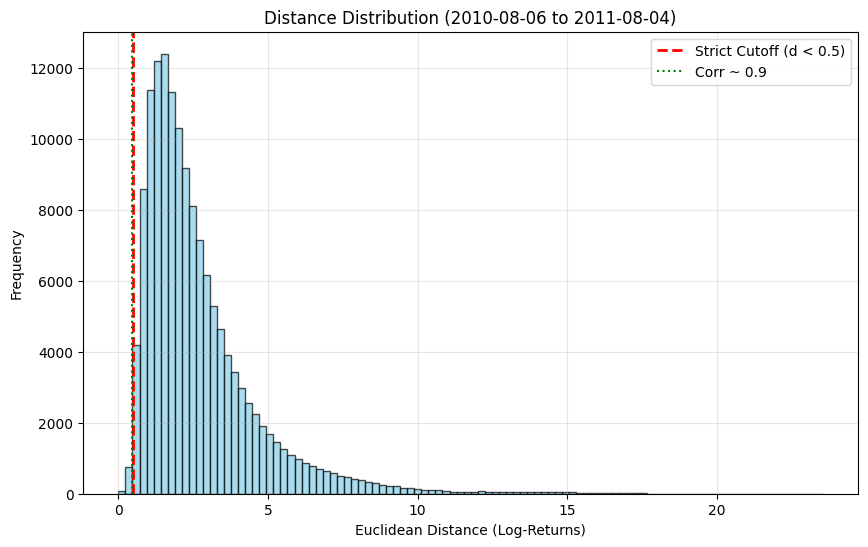

In [85]:
# --- THỰC THI (Thay đổi ngày ở đây) ---
if 'prices_df' in locals():
    # Thử kiểm tra giai đoạn COVID-19
    analyze_distance_distribution(prices_df, start_date='2010-01-01')

In [86]:
# Cell 6.2: Interactive Distance Chart (Flexible Date)
import altair as alt

def run_interactive_chart(prices_df, start_date='2010-01-01'):
    print(f"⏳ Đang tạo biểu đồ tương tác cho giai đoạn từ: {start_date}...")

    try:
        # 1. Cắt dữ liệu
        idx_start = prices_df.index.searchsorted(pd.to_datetime(start_date))
        formation_data = prices_df.iloc[idx_start : idx_start + 252]

        # 2. Tính Distance
        selector = DistanceSelector(prices_df)
        dist_df = selector.calculate_distance_matrix(formation_data)

        mask = np.triu(np.ones(dist_df.shape), k=1).astype(bool)
        all_distances = dist_df.where(mask).stack().values

        # 3. Binning
        counts, bin_edges = np.histogram(all_distances, bins=200)
        hist_data = pd.DataFrame({
            'Count': counts,
            'BinStart': bin_edges[:-1],
            'BinEnd': bin_edges[1:]
        })

        # 4. Vẽ Altair Chart
        base = alt.Chart(hist_data).encode(
            x=alt.X('BinStart', bin=alt.Bin(binned=True), title='Distance'),
            x2='BinEnd',
            y=alt.Y('Count'),
            tooltip=['BinStart', 'BinEnd', 'Count']
        )
        bars = base.mark_bar(color='#87CEEB', opacity=0.8)

        # Ngưỡng đỏ 0.5
        rule = alt.Chart(pd.DataFrame({'x': [0.5]})).mark_rule(color='red').encode(x='x')

        chart = (bars + rule).properties(
            title=f'Interactive Distribution (Start: {start_date})',
            width=800, height=400
        ).interactive()

        return chart
    except Exception as e:
        print(f"Lỗi: {e}")
        return None



In [87]:
# --- THỰC THI ---
if 'prices_df' in locals():
    # Thử xem năm 2022 (Lạm phát)
    chart = run_interactive_chart(prices_df, start_date='2010-01-01')
    if chart: chart.display()

⏳ Đang tạo biểu đồ tương tác cho giai đoạn từ: 2010-01-01...


alt.LayerChart(...)

In [88]:
# Cell 6.3: Visualize Top Strict Pairs (Flexible Date)

def visualize_top_pairs_by_date(prices_df, start_date='2010-01-01', num_plots=3):
    print(f"--- TÌM & VẼ CẶP TỐT NHẤT TỪ {start_date} ---")

    try:
        # 1. Cắt dữ liệu
        idx_start = prices_df.index.searchsorted(pd.to_datetime(start_date))
        formation_data = prices_df.iloc[idx_start : idx_start + 252]

        # 2. Lọc cặp (Strict Mode < 0.5)
        selector = DistanceSelector(prices_df)
        top_candidates = selector.get_strict_candidates(formation_data, dist_threshold=0.5)

        print(f"-> Tìm thấy {len(top_candidates)} cặp (Distance < 0.5)")

        if top_candidates.empty:
            print("⚠️ Không có cặp nào đạt chuẩn Strict trong giai đoạn này.")
            return

        # 3. Vẽ biểu đồ
        plt.figure(figsize=(15, 5 * num_plots))
        pairs_list = top_candidates.index.tolist()

        for i in range(min(num_plots, len(pairs_list))):
            t1, t2 = pairs_list[i]
            dist_val = top_candidates.iloc[i]

            # Chuẩn hóa (Log Return)
            s1 = formation_data[t1] - formation_data[t1].iloc[0]
            s2 = formation_data[t2] - formation_data[t2].iloc[0]

            ax = plt.subplot(num_plots, 1, i+1)
            ax.plot(s1, label=t1)
            ax.plot(s2, label=t2)
            ax.fill_between(s1.index, s1, s2, color='gray', alpha=0.1)

            ax.set_title(f"Rank {i+1}: {t1} vs {t2} | Dist: {dist_val:.4f} | Period: {formation_data.index[0].year}")
            ax.legend()
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Lỗi: {e}")


--- TÌM & VẼ CẶP TỐT NHẤT TỪ 2010-01-01 ---
-> Tìm thấy 1086 cặp (Distance < 0.5)


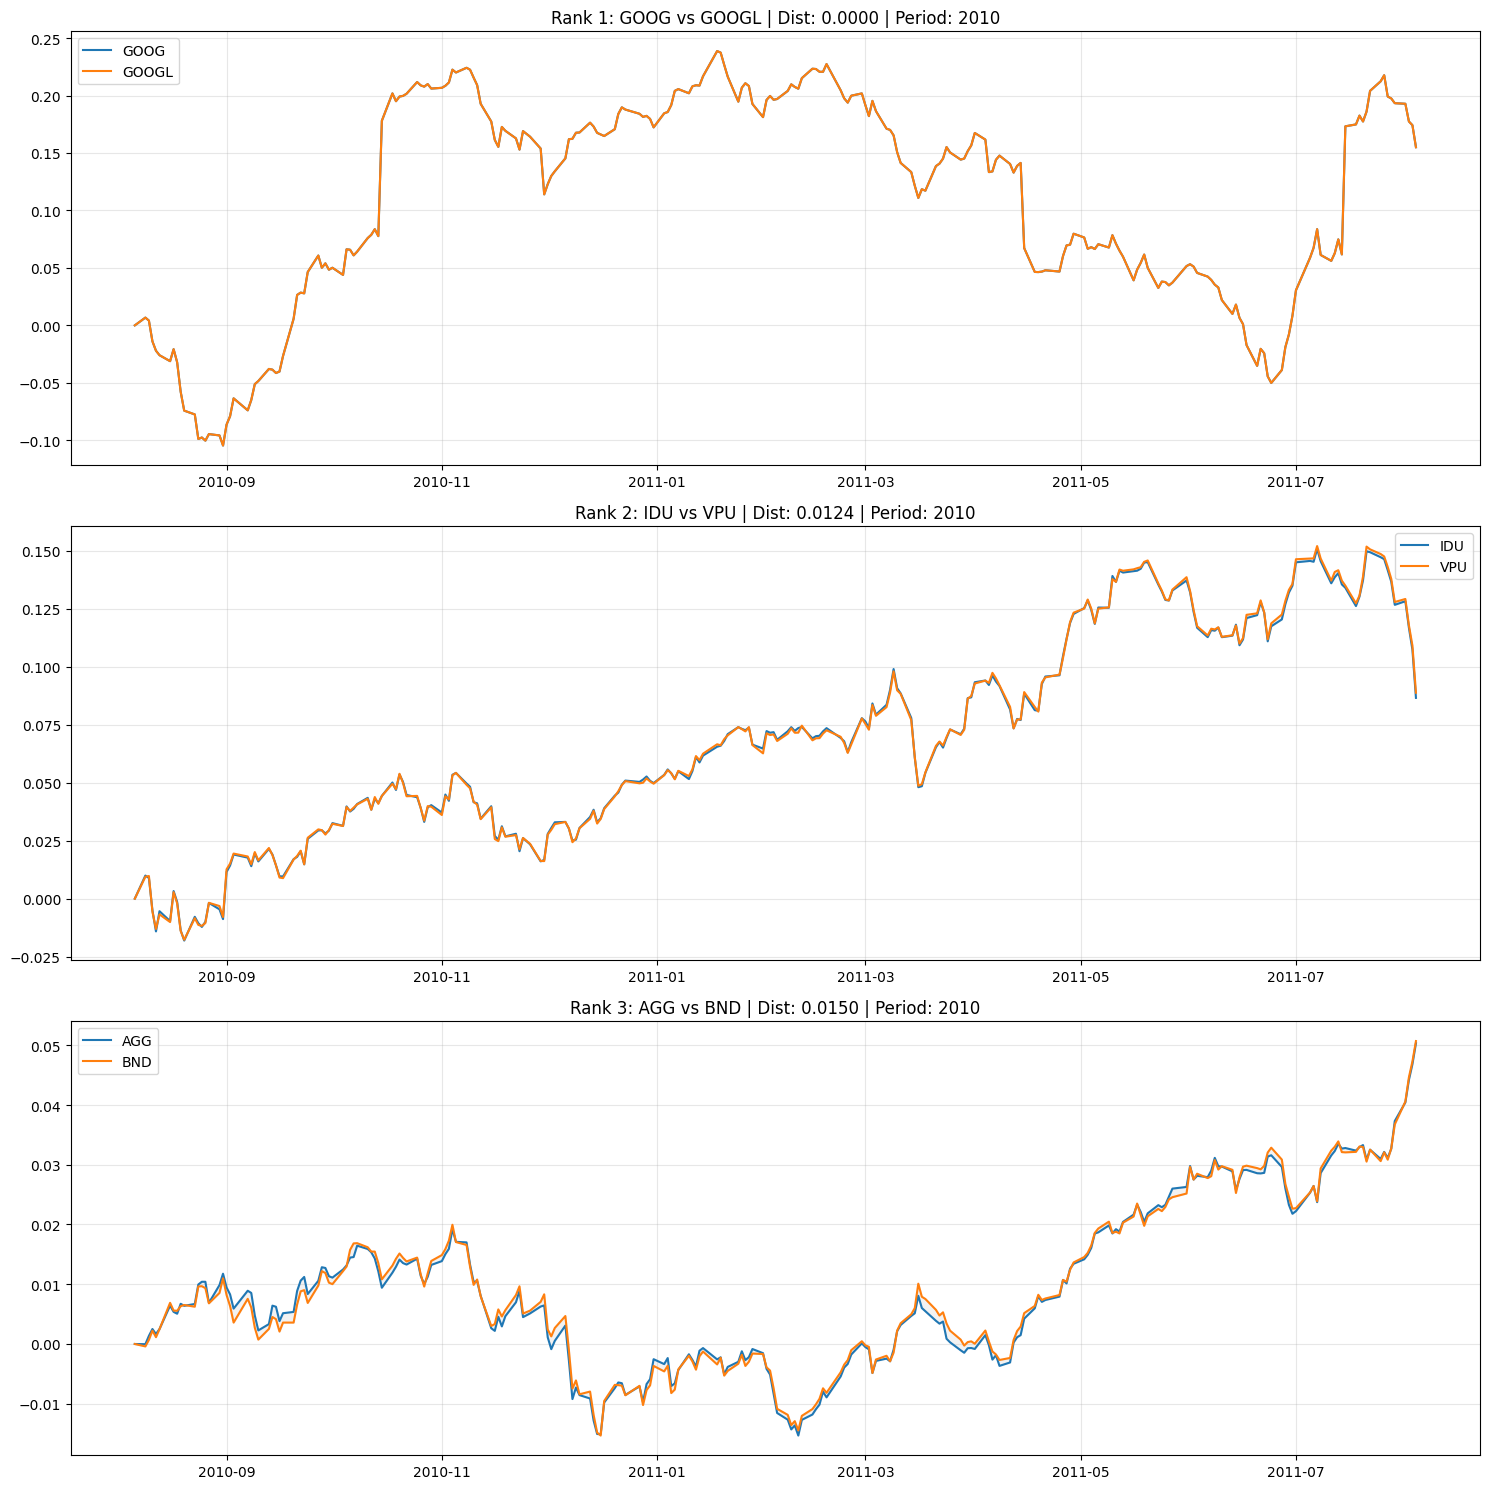

In [89]:
# --- THỰC THI ---
if 'prices_df' in locals():
    # Thử xem năm 2015
    visualize_top_pairs_by_date(prices_df, start_date='2010-01-01')

In [90]:
# Cell 6.4: List Top Pairs Report (Flexible Date)

def report_top_pairs(prices_df, start_date='2010-01-01', top_n=10):
    print(f"--- BÁO CÁO CẶP TIỀM NĂNG (Start: {start_date}) ---")
    try:
        idx_start = prices_df.index.searchsorted(pd.to_datetime(start_date))
        formation_data = prices_df.iloc[idx_start : idx_start + 252]

        selector = DistanceSelector(prices_df)
        candidates = selector.get_strict_candidates(formation_data, dist_threshold=0.5)

        print(f"Tổng số cặp đạt chuẩn (d < 0.5): {len(candidates)}")

        if not candidates.empty:
            print(f"\nTop {top_n} cặp có tương quan cao nhất:")
            print(candidates.head(top_n))
        else:
            print("Không tìm thấy cặp nào.")

    except Exception as e:
        print(f"Lỗi: {e}")



In [91]:
# --- THỰC THI ---
if 'prices_df' in locals():
    # Kiểm tra năm 2010
    report_top_pairs(prices_df, start_date='2010-01-01')

--- BÁO CÁO CẶP TIỀM NĂNG (Start: 2010-01-01) ---
Tổng số cặp đạt chuẩn (d < 0.5): 1086

Top 10 cặp có tương quan cao nhất:
GOOG  GOOGL    0.000002
IDU   VPU      0.012391
AGG   BND      0.015013
IWD   VTV      0.048925
ACWI  VT       0.060621
EFA   VEA      0.062773
IGM   VGT      0.069243
IWF   VUG      0.070699
IYH   XLV      0.076166
IWN   VBR      0.080207
dtype: float64


# 🧪 Module 5: Pair Validation & Smart Scoring (The Gatekeeper)

## 1. Objective: Quality over Quantity
While Module 4 (Distance Selection) successfully filtered the universe down to pairs that exhibit high historical co-movement ($d < 0.5$), it does not guarantee that these pairs are currently tradable or profitable.

This module acts as a strict **"Gatekeeper"**. Its mission is twofold:
1.  **Validate:** rigorously test each candidate pair against statistical arbitrage criteria (Stationarity, Mean Reversion).
2.  **Rank:** Determine which pairs offer the best balance of risk and reward using a novel **"Smart Scoring"** mechanism.

---

## 2. The Validation Pipeline (The 4 Gates)
We subject each candidate pair to a rigorous **4-Step Stress Test**, directly inspired by *Vidyamurthy's "Testing for Tradability"* framework (Chapter 7).

### 📐 Gate 1: Constructing the Spread (TLS Beta)
Using **Total Least Squares (TLS)** estimation, we derive the optimal hedge ratio ($\beta$) to construct the spread:
$$Spread_t = \ln(P_{A,t}) - \beta_{TLS} \ln(P_{B,t})$$
* **Why TLS?** Unlike OLS, TLS accounts for measurement errors in both assets, providing a more robust estimate of the long-term equilibrium relationship.

### 📉 Gate 2: Profit Potential (Volatility Filter)
We calculate the standard deviation of the spread ($\sigma_{spread}$).
* **Constraint:** $\sigma_{spread} \ge 0.5\%$ (0.005).
* **Rationale:** In a realistic trading environment with transaction costs (commissions + slippage), a spread with extremely low volatility offers a **Negative Expected Value**. We must ensure there is enough "meat on the bone" to cover costs.

### ⏱️ Gate 3: Mean Reversion Dynamics (OU Process)
We fit the spread to the **Ornstein-Uhlenbeck (OU)** process to determine the **Half-Life** ($HL$) and **Mean Reversion Speed** ($\theta$):
$$dX_t = \theta (\mu - X_t)dt + \sigma dW_t$$
* **Constraint:** $1 \le HL \le 30$ days.
* **Rationale:**
    * $HL < 1$: Likely microstructure noise or bid-ask bounce.
    * $HL > 30$: Capital is tied up too long, increasing opportunity cost and exposure to "Mean Drift" risk.

### 📊 Gate 4: Statistical Stationarity (ADF & Zero-Crossing)
1.  **Augmented Dickey-Fuller (ADF) Test:**
    * **Null Hypothesis ($H_0$):** The spread has a Unit Root (Random Walk).
    * **Constraint:** Reject $H_0$ at **95% Confidence** ($p < 0.05$).
2.  **Zero-Crossing Rate (ZCR):**
    * **Constraint:** $\text{ZCR} \ge 4$ times/year.
    * **Rationale:** Ensures liquidity and confirms that the spread physically reverts to the mean frequently enough to generate trading signals.

---

## 3. The "Smart Scoring" Mechanism (Optimization)
**Problem:** In traditional backtests, sorting pairs by **Volatility** often selects pairs with unstable relationships that are prone to divergence (high risk).

**Solution:** We introduce a composite **Smart Score** to rank pairs based on a weighted average of three critical factors:

$$Score = 0.4 \times \text{Rank}(\theta) + 0.3 \times \text{Rank}(ADF_{pval}) + 0.3 \times \text{Rank}(\sigma)$$

| Factor | Metric | Weight | Rationale |
| :--- | :--- | :--- | :--- |
| **Speed** | $\theta$ (Theta) | **40%** | We prioritize pairs that revert *fast* to maximize capital turnover. |
| **Reliability** | $ADF$ p-value | **30%** | We value statistical confidence. A lower p-value implies stronger stationarity. |
| **Profit** | $\sigma$ (Volatility) | **30%** | We prefer higher volatility for profit, but not at the expense of stability. |

**Outcome:** The final output is a list of **"Elite Pairs"**—statistically robust, fast-acting, and sufficiently profitable candidates ready for the Trading Engine.

In [116]:
# Cell 7: Pair Validation (Smart Scoring & Mu Fixed)
# MODULE: VALIDATION
# ==============================================================================
# PHẦN 1: ĐỊNH NGHĨA HÀM
# ==============================================================================

from tqdm.notebook import tqdm
import pandas as pd
import numpy as np

def validate_pairs(formation_data, candidates):
    """
    Thực hiện kiểm định tính chất thống kê của các cặp ứng viên.
    Input: formation_data (Log-Prices), candidates (List/Series cặp).
    Output: DataFrame các cặp đạt chuẩn Tradability với Smart Score.
    """
    # Safety Check: Dữ liệu rỗng
    if formation_data.empty: return pd.DataFrame()

    # Safety Check: Raw Price vs Log Price
    if formation_data.iloc[0, 0] > 50:
        print("⚠️ CẢNH BÁO: Dữ liệu có vẻ là RAW PRICE. Cần Log-Price.")
        return pd.DataFrame()

    results = []

    # Xử lý input đầu vào (chấp nhận cả Index hoặc List)
    pair_list = candidates.index if isinstance(candidates, pd.Series) else candidates

    print(f"--- BẮT ĐẦU KIỂM TRA TRADABILITY (SL Ứng viên: {len(pair_list)}) ---")

    for t1, t2 in tqdm(pair_list, desc="Running Cointegration Tests"):
        try:
            s1 = formation_data[t1]
            s2 = formation_data[t2]

            # 1. TLS Beta & Spread Construction
            # Vidyamurthy Ch.7: Estimate Linear Relationship
            beta = Econometrics.tls_hedge_ratio(s1, s2)
            spread = s1 - beta * s2

            # 2. Profit Potential (Volatility Check)
            # Spread Volatility > 0.5% để đảm bảo biên lợi nhuận
            vol = np.std(spread)
            if vol < 0.005: continue

            # 3. Mean Reversion (OU Process)
            # Fit Spread vào mô hình OU để lấy Theta, Mu, Sigma
            ou = Econometrics.fit_ou_process(spread)

            # Half-Life Check (1 - 30 days)
            # Nhanh quá (<1) là nhiễu, Chậm quá (>30) là rủi ro chôn vốn
            if not (1 <= ou['half_life'] <= 30): continue

            # 4. Stationarity Check
            # ADF Test (p < 0.05) & Zero Crossing (> 4 lần/năm)
            if ou['adf_pvalue'] >= 0.05: continue

            zc_count, zc_rate = Econometrics.calculate_zero_crossing_rate(spread)
            if zc_rate < 4: continue

            # --- LƯU KẾT QUẢ (QUAN TRỌNG: CÓ MU) ---
            results.append({
                'Leg1': t1, 'Leg2': t2,
                'Beta': round(beta, 4),
                'Spread_Vol': round(vol, 4),
                'HalfLife': round(ou['half_life'], 1),
                'Z_Cross': round(zc_rate, 1),
                'ADF': round(ou['adf_pvalue'], 4),
                'Theta': round(ou['theta'], 3),
                'Mu': round(ou['mu'], 5) # <--- ĐÃ TRẢ VỀ MU CHO CELL 9 SỬ DỤNG
            })

        except:
            continue

    df = pd.DataFrame(results)

    if not df.empty:
        # --- SMART SCORING (CHẤM ĐIỂM THÔNG MINH) ---
        # Mục tiêu: Tìm cặp "Vừa nhanh, Vừa chuẩn, Vừa có ăn"

        # 1. Rank Theta (Tốc độ): Hồi quy càng nhanh càng tốt -> Rank cao
        df['Rank_Theta'] = df['Theta'].rank(ascending=True)

        # 2. Rank ADF (Độ tin cậy): P-value càng nhỏ càng tốt -> Rank cao (đảo ngược)
        df['Rank_ADF'] = df['ADF'].rank(ascending=False)

        # 3. Rank Volatility (Lợi nhuận): Biến động càng cao càng tốt -> Rank cao
        df['Rank_Vol'] = df['Spread_Vol'].rank(ascending=True)

        # Công thức tổng hợp (Trọng số tùy chỉnh)
        # 40% Tốc độ + 30% Tin cậy + 30% Lợi nhuận
        df['Score'] = 0.4 * df['Rank_Theta'] + 0.3 * df['Rank_ADF'] + 0.3 * df['Rank_Vol']

        # Sắp xếp theo điểm số cao nhất
        df = df.sort_values('Score', ascending=False)

        # Dọn dẹp các cột phụ cho gọn
        df = df.drop(columns=['Rank_Theta', 'Rank_ADF', 'Rank_Vol'])

    print(f"-> HOÀN TẤT. Tìm thấy {len(df)} cặp đạt chuẩn Tradability.")
    return df

# ==============================================================================
# PHẦN 2: THỰC THI (TEST)
# ==============================================================================
def execute_cell7_test(target_date_str='2010-01-01', dist_threshold=0.5):
    # Kiểm tra biến cần thiết
    if 'prices_df' not in globals() or 'DistanceSelector' not in globals():
        print("❌ Lỗi: Cần chạy Cell 3 và Cell 6 trước.")
        return

    print(f"\n--- TEST DATA: {target_date_str} ---")
    try:
        # 1. Chuẩn bị dữ liệu
        start_idx = prices_df.index.searchsorted(pd.to_datetime(target_date_str))
        sample_formation = prices_df.iloc[start_idx : start_idx + 252]

        if len(sample_formation) < 252:
            print("❌ Không đủ dữ liệu.")
            return

        print(f"Date Range: {sample_formation.index[0].date()} -> {sample_formation.index[-1].date()}")

        # 2. Lọc Thô (Distance)
        selector = DistanceSelector(prices_df)
        candidates = selector.get_strict_candidates(sample_formation, dist_threshold=dist_threshold)

        if not candidates.empty:
            print(f"Distance Filter: {len(candidates)} pairs.")

            # 3. Lọc Tinh (Tradability & Smart Score)
            final_pairs = validate_pairs(sample_formation, candidates)

            if not final_pairs.empty:
                print("\nTOP 5 CẶP (SMART SCORE CAO NHẤT):")
                print(final_pairs.head(5))
                return final_pairs
            else:
                print("⚠️ Không có cặp nào qua được vòng Tradability.")
        else:
            print("⚠️ Không tìm thấy ứng viên nào từ bước Distance Filter.")

    except Exception as e:
        print(f"Error: {e}")



In [95]:
# Chạy test ngay
if 'prices_df' in locals():
    # Thử năm 2010
    _ = execute_cell7_test('2010-01-01')


--- TEST DATA: 2010-01-01 ---
Date Range: 2010-08-06 -> 2011-08-04
Distance Filter: 1086 pairs.
--- BẮT ĐẦU KIỂM TRA TRADABILITY (SL Ứng viên: 1086) ---


Running Cointegration Tests:   0%|          | 0/1086 [00:00<?, ?it/s]

-> HOÀN TẤT. Tìm thấy 169 cặp đạt chuẩn Tradability.

TOP 5 CẶP (SMART SCORE CAO NHẤT):
    Leg1 Leg2    Beta  Spread_Vol  HalfLife  Z_Cross     ADF  Theta       Mu  \
138  AEE  AMT  1.3412      0.0386       6.7     39.0  0.0017  0.103 -2.04461   
142   GD  PKG  1.0425      0.0308       5.9     26.0  0.0028  0.117  0.93619   
72   DGX  NOC  1.0605      0.0295       7.5     21.0  0.0024  0.093 -0.32014   
135  AMT  XEL  0.9961      0.0291       7.3     32.0  0.0027  0.094  0.97276   
141  CSX  PLD  0.9742      0.0288       7.4     31.0  0.0021  0.094 -1.17207   

      Score  
138  159.15  
142  151.90  
72   142.65  
135  141.00  
141  141.00  


# 🏭 Module 6: Pair Selection Pipeline (The Orchestrator)

## 1. Objective: Solving the "Static Bias" Problem
A common pitfall in quantitative research is **Static Pair Selection**: identifying pairs based on the *entire* history (e.g., 2010-2025) and then backtesting on the same period. This introduces **Look-Ahead Bias** and **Survivorship Bias**, rendering the results scientifically invalid.

**Module 6** functions as the **Pipeline Orchestrator**. It dynamically selects pairs based *only* on the data available at a specific point in time ($T$), mimicking the constraints of a real-world trader.

---

## 2. The Selection Funnel Architecture
The pipeline integrates the components from **Module 4 (Distance)** and **Module 5 (Validation)** into a coherent filtering mechanism.

### The "Funnel" Process
For any given **Formation Start Date** ($T_0$):

1.  **Data Slicing (The Window):**
    * We extract a strictly bounded training window: $[T_0, T_0 + 252 \text{ days}]$.
    * *Constraint:* No data point beyond $T_0 + 252$ is accessible to the algorithm.

2.  **Filter 1: Strict Dimensionality Reduction (Module 4)**
    * **Input:** Entire Universe ($\approx 600$ tickers).
    * **Action:** Calculate Euclidean Distance Matrix on cumulative log-returns.
    * **Cutoff:** Keep only pairs with `Distance < dist_threshold` (Default 0.5).
    * **Output:** Raw Candidates.

3.  **Filter 2: Tradability & Smart Scoring (Module 5)**
    * **Input:** Raw Candidates from Filter 1.
    * **Action:** Run Cointegration Tests (Engle-Granger), OU Process fitting, Stationarity checks (ADF), and apply the **Smart Scoring** algorithm.
    * **Constraint:** Reject pairs with Non-stationary spread or extremely slow mean reversion.
    * **Output:** Validated Pairs sorted by Score.

---

## 3. Ensuring Regime Independence
By re-running this pipeline at different time steps (e.g., every 6 months), the system adapts to **Market Regimes**:
* **In 2010 (Post-Crisis):** It might select defensive utilities pairs (High stability).
* **In 2020 (High Volatility):** It might select tech/growth pairs (Fast reversion).

This dynamic adaptation proves that the strategy's alpha comes from the **algorithm's logic**, not from lucky stock picking.

In [137]:
# Cell 8: Pair Selection Engine (Dynamic Date Input)
# MODULE: PIPELINE ORCHESTRATOR
# ==============================================================================
# MỤC TIÊU:
# Tự động hóa quy trình chọn cặp từ bất kỳ ngày bắt đầu nào.
# Dependency: Cần chạy Cell 5 (Econometrics), Cell 6 (Distance), Cell 7 (Validation) trước.
# ==============================================================================

def run_pair_selection_pipeline(prices_df, start_date_str, formation_days=252, dist_threshold = 0.5):
    """
    Quy trình chọn cặp khép kín (End-to-End Selection Pipeline).

    Input:
        start_date_str: Ngày bắt đầu giai đoạn Formation (vd: '2023-01-01').
    Output:
        DataFrame: Danh sách các cặp đạt chuẩn Tradability.
    """
    print(f"🔵 BƯỚC 1: KHỞI ĐỘNG BỘ LỌC (Start Date: {start_date_str})")

    # 1. Xác định khung thời gian Formation
    try:
        target_date = pd.to_datetime(start_date_str)
        start_idx = prices_df.index.searchsorted(target_date)
    except:
        print("❌ Lỗi: Định dạng ngày không hợp lệ.")
        return pd.DataFrame()

    end_idx = start_idx + formation_days

    # Kiểm tra biên dữ liệu
    if end_idx > len(prices_df):
        print(f"❌ Lỗi: Không đủ dữ liệu 1 năm tính từ {start_date_str}.")
        return pd.DataFrame()

    # Cắt dữ liệu Formation (Log-Prices)
    formation_data = prices_df.iloc[start_idx : end_idx]
    print(f"   [i] Dữ liệu Formation: {formation_data.index[0].date()} -> {formation_data.index[-1].date()}")

    # 2. Gọi Cell 6: Distance Filter (Lọc thô)
    try:
        # Modified print statement to show the actual threshold
        print(f"   [+] Đang chạy Distance Filter (Strict Mode < {dist_threshold})...")
        selector = DistanceSelector(prices_df)
        # Lọc cứng distance < 0.5
        candidates = selector.get_strict_candidates(formation_data, dist_threshold = dist_threshold)

        if candidates.empty:
            print(f"   ⚠️ Cảnh báo: Không tìm thấy cặp nào thỏa mãn Distance < {dist_threshold}.")
            return pd.DataFrame()

    except NameError:
        print("❌ Lỗi: Chưa chạy Cell 6 (DistanceSelector).")
        return pd.DataFrame()

    # 3. Gọi Cell 7: Tradability Filter (Lọc tinh)
    try:
        print(f"   [+] Đang chạy Tradability Filter trên {len(candidates)} ứng viên...")
        final_pairs = validate_pairs(formation_data, candidates)

    except NameError:
        print("❌ Lỗi: Chưa chạy Cell 7 (validate_pairs).")
        return pd.DataFrame()

    print(f"✅ HOÀN TẤT. Tìm thấy {len(final_pairs)} cặp đạt chuẩn.")
    return final_pairs



In [97]:
# --- THỰC THI (USER INPUT) ---
# Bạn có thể đổi ngày ở đây thoải mái
TARGET_DATE = '2010-01-01'

# Gọi hàm để lấy danh sách cặp (Lưu vào biến global để Cell 9 dùng)
selected_pairs_df = run_pair_selection_pipeline(prices_df, start_date_str=TARGET_DATE)

# Xem thử kết quả
if not selected_pairs_df.empty:
    print("\nTOP 5 CẶP ĐƯỢC CHỌN:")
    print(selected_pairs_df.head(5))

🔵 BƯỚC 1: KHỞI ĐỘNG BỘ LỌC (Start Date: 2010-01-01)
   [i] Dữ liệu Formation: 2010-08-06 -> 2011-08-04
   [+] Đang chạy Distance Filter (Strict Mode < 0.5)...
   [+] Đang chạy Tradability Filter trên 1086 ứng viên...
--- BẮT ĐẦU KIỂM TRA TRADABILITY (SL Ứng viên: 1086) ---


Running Cointegration Tests:   0%|          | 0/1086 [00:00<?, ?it/s]

-> HOÀN TẤT. Tìm thấy 169 cặp đạt chuẩn Tradability.
✅ HOÀN TẤT. Tìm thấy 169 cặp đạt chuẩn.

TOP 5 CẶP ĐƯỢC CHỌN:
    Leg1 Leg2    Beta  Spread_Vol  HalfLife  Z_Cross     ADF  Theta       Mu  \
138  AEE  AMT  1.3412      0.0386       6.7     39.0  0.0017  0.103 -2.04461   
142   GD  PKG  1.0425      0.0308       5.9     26.0  0.0028  0.117  0.93619   
72   DGX  NOC  1.0605      0.0295       7.5     21.0  0.0024  0.093 -0.32014   
135  AMT  XEL  0.9961      0.0291       7.3     32.0  0.0027  0.094  0.97276   
141  CSX  PLD  0.9742      0.0288       7.4     31.0  0.0021  0.094 -1.17207   

      Score  
138  159.15  
142  151.90  
72   142.65  
135  141.00  
141  141.00  


# 🏭 Module 6: Pair Selection Pipeline (The Orchestrator)

## 1. Objective: Solving the "Static Bias" Problem
A common pitfall in quantitative research is **Static Pair Selection**: identifying pairs based on the *entire* history (e.g., 2010-2025) and then backtesting on the same period. This introduces **Look-Ahead Bias** and **Survivorship Bias**, rendering the results scientifically invalid.

**Module 6** functions as the **Pipeline Orchestrator**. It dynamically selects pairs based *only* on the data available at a specific point in time ($T$), mimicking the constraints of a real-world trader.

---

## 2. The Selection Funnel Architecture
The pipeline integrates the components from **Module 4 (Distance)** and **Module 5 (Validation)** into a coherent filtering mechanism.

### The "Funnel" Process
For any given **Formation Start Date** ($T_0$):

1.  **Data Slicing (The Window):**
    * We extract a strictly bounded training window: $[T_0, T_0 + 252 \text{ days}]$.
    * *Constraint:* No data point beyond $T_0 + 252$ is accessible to the algorithm.

2.  **Filter 1: Strict Dimensionality Reduction (Module 4)**
    * **Input:** Entire Universe ($\approx 600$ tickers).
    * **Action:** Calculate Euclidean Distance Matrix on cumulative log-returns.
    * **Cutoff:** Keep only pairs with `Distance < dist_threshold` (Default 0.5).
    * **Output:** Raw Candidates.

3.  **Filter 2: Tradability & Smart Scoring (Module 5)**
    * **Input:** Raw Candidates from Filter 1.
    * **Action:** Run Cointegration Tests (Engle-Granger), OU Process fitting, Stationarity checks (ADF), and apply the **Smart Scoring** algorithm.
    * **Constraint:** Reject pairs with Non-stationary spread or extremely slow mean reversion.
    * **Output:** Validated Pairs sorted by Score.

---

## 3. Ensuring Regime Independence
By re-running this pipeline at different time steps (e.g., every 6 months), the system adapts to **Market Regimes**:
* **In 2010 (Post-Crisis):** It might select defensive utilities pairs (High stability).
* **In 2020 (High Volatility):** It might select tech/growth pairs (Fast reversion).

This dynamic adaptation proves that the strategy's alpha comes from the **algorithm's logic**, not from lucky stock picking.

In [130]:
# Cell 9: Trading Simulation Engine (Trade ALL Pairs Default)
# MODULE: BACKTESTING & RISK MANAGEMENT
# Reference: Vidyamurthy Chapter 8, Bailey et al. (Stop Loss Logic)
# ==============================================================================
# MỤC TIÊU:
# 1. Chạy mô phỏng giao dịch độc lập.
# 2. Tích hợp STOP-LOSS (Z > 4.0).
# 3. Mặc định trade TOÀN BỘ các cặp đạt chuẩn (tránh Selection Bias).
# ==============================================================================

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

class TradingSimulation:
    def __init__(self, prices_df, cost_bps=10, stop_loss_z=4.0, time_stop_factor=2.0, entry_z_min=0.5):
        """
        Khởi tạo bộ mô phỏng với các tham số quản trị rủi ro.
        """
        self.prices_df = prices_df
        self.formation_days = 252 # 1 năm học
        self.trading_days = 126   # 6 tháng hành động
        self.cost_bps = cost_bps
        self.stop_loss_z = stop_loss_z
        self.time_stop_factor = time_stop_factor
        self.entry_z_min = entry_z_min

    def simulate_single_pair(self, leg1, leg2, start_date_str):
        # 1. Xác định Index
        try:
            start_idx = self.prices_df.index.searchsorted(pd.to_datetime(start_date_str))
        except IndexError: return None

        idx_end_form = start_idx + self.formation_days
        idx_end_trade = idx_end_form + self.trading_days

        if idx_end_trade > len(self.prices_df): return None

        # 2. Tái lập tham số (In-Sample)
        s1_form = self.prices_df[leg1].iloc[start_idx : idx_end_form]
        s2_form = self.prices_df[leg2].iloc[start_idx : idx_end_form]

        try:
            beta = Econometrics.tls_hedge_ratio(s1_form, s2_form)
            spread_form = s1_form - beta * s2_form
            ou = Econometrics.fit_ou_process(spread_form)

            theta = max(ou['theta'], 0.001)
            thresh_val = Econometrics.bertram_optimal_threshold(theta, ou['sigma'])

            if np.isnan(thresh_val): z_entry = 2.0
            else: z_entry = max(thresh_val / ou['sigma'], self.entry_z_min)
        except:
            return None

        # 3. Trading (Out-of-Sample)
        s1_trade = self.prices_df[leg1].iloc[idx_end_form : idx_end_trade]
        s2_trade = self.prices_df[leg2].iloc[idx_end_form : idx_end_trade]

        spread_oos = s1_trade - beta * s2_trade
        z_score = (spread_oos - ou['mu']) / ou['sigma']

        # 4. Vòng lặp giao dịch
        position = 0; pnl = []; days_held = 0; entry_price = 0.0; trades = 0
        max_hold_days = int(ou['half_life'] * self.time_stop_factor)

        for t in range(len(z_score)):
            z = z_score.iloc[t]
            prc = spread_oos.iloc[t]
            day_pnl = 0.0

            # --- EXIT LOGIC ---
            if position != 0:
                days_held += 1
                exit_signal = False

                # Take Profit
                if (position == 1 and z >= 0) or (position == -1 and z <= 0): exit_signal = True
                # Time Stop
                elif days_held >= max_hold_days: exit_signal = True
                # Stop Loss
                elif self.stop_loss_z is not None and abs(z) > self.stop_loss_z: exit_signal = True

                if exit_signal:
                    gross_pnl = (prc - entry_price) * position
                    cost = self.cost_bps * 0.0001 * 4
                    day_pnl = gross_pnl - cost
                    position = 0; days_held = 0; trades += 1

            # --- ENTRY LOGIC ---
            elif position == 0:
                is_safe = True
                if self.stop_loss_z is not None and abs(z) >= self.stop_loss_z: is_safe = False

                if is_safe:
                    if z > z_entry: position = -1; entry_price = prc
                    elif z < -z_entry: position = 1; entry_price = prc

            pnl.append(day_pnl)

        return {
            'Leg1': leg1, 'Leg2': leg2,
            'Total_PnL': np.sum(pnl),
            'Trades': trades,
            'Beta': beta
        }

    def execute_test_run(self, start_date_str, top_n=None, dist_threshold=None):
        """
        Hàm thực thi Backtest.
        top_n: Số lượng cặp muốn trade. Mặc định là None (Trade TOÀN BỘ).
        """
        print(f"🔴 KHỞI ĐỘNG TRADING ENGINE (Formation Start: {start_date_str})")

        # 1. Gọi Pipeline chọn cặp (Cell 8)
        if 'run_pair_selection_pipeline' not in globals():
            print("❌ Lỗi: Cần chạy Cell 8 trước.")
            return pd.DataFrame()

        print("   [1/2] Đang gọi bộ lọc cặp (Cell 8)...")
        try:
            pairs_df = run_pair_selection_pipeline(self.prices_df, start_date_str, dist_threshold=dist_threshold)
        except TypeError:
            pairs_df = run_pair_selection_pipeline(self.prices_df, start_date_str)

        if pairs_df.empty:
            print("   ⚠️ Không tìm thấy cặp nào.")
            return pd.DataFrame()

        # 2. Xử lý số lượng cặp (Top N hay All)
        if top_n is None:
            trade_pairs = pairs_df
            print(f"   [i] Chế độ: Trade TOÀN BỘ {len(trade_pairs)} cặp đạt chuẩn.")
        else:
            trade_pairs = pairs_df.head(top_n)
            print(f"   [i] Chế độ: Trade TOP {len(trade_pairs)} cặp (trên tổng số {len(pairs_df)}).")

        # Hiển thị ngày Trade thực tế
        try:
            start_idx = self.prices_df.index.searchsorted(pd.to_datetime(start_date_str))
            trade_date = self.prices_df.index[start_idx + self.formation_days].date()
            print(f"   [i] Ngày Bắt Đầu Trade (Real Money): {trade_date}")
        except: pass

        print(f"   [2/2] Đang chạy mô phỏng...")

        # 3. Chạy Backtest
        results = []
        for _, row in tqdm(trade_pairs.iterrows(), total=len(trade_pairs), leave=False):
            res = self.simulate_single_pair(row['Leg1'], row['Leg2'], start_date_str)
            if res: results.append(res)

        res_df = pd.DataFrame(results)

        if not res_df.empty:
            total_ret = res_df['Total_PnL'].sum()
            avg_ret = res_df['Total_PnL'].mean()
            win_rate = (res_df['Total_PnL'] > 0).mean() * 100

            print(f"\n📊 KẾT QUẢ BACKTEST:")
            print(f"   - Tổng Lợi Nhuận (Log): {total_ret:.4f}")
            print(f"   - Trung Bình/Cặp: {avg_ret:.4f}")
            print(f"   - Win Rate: {win_rate:.1f}%")
            return res_df.sort_values('Total_PnL', ascending=False)
        else:
            return pd.DataFrame()


In [140]:
# --- VÍ DỤ CÁCH CHẠY ---
if 'prices_df' in locals():
    # Khởi tạo Engine (Stoploss = 4.0)
    sim = TradingSimulation(prices_df, cost_bps=10, stop_loss_z = None)

    # Chạy thử với mặc định (Trade ALL pairs)
    print("\n=== TEST RUN: ALL PAIRS ===")
    # Truyền biến dist_threshold
    custom_dist_threshold = 0.6
    res_all = sim.execute_test_run('2020-01-01', top_n = None,  dist_threshold=custom_dist_threshold)

    if not res_all.empty:
        print("\n🏆 Top 5 Cặp Lãi Nhất:")
        print(res_all.head(5))


=== TEST RUN: ALL PAIRS ===
🔴 KHỞI ĐỘNG TRADING ENGINE (Formation Start: 2020-01-01)
   [1/2] Đang gọi bộ lọc cặp (Cell 8)...
🔵 BƯỚC 1: KHỞI ĐỘNG BỘ LỌC (Start Date: 2020-01-01)
   [i] Dữ liệu Formation: 2020-01-02 -> 2020-12-30
   [+] Đang chạy Distance Filter (Strict Mode < 0.6)...
   [+] Đang chạy Tradability Filter trên 220 ứng viên...
--- BẮT ĐẦU KIỂM TRA TRADABILITY (SL Ứng viên: 220) ---


Running Cointegration Tests:   0%|          | 0/220 [00:00<?, ?it/s]

-> HOÀN TẤT. Tìm thấy 34 cặp đạt chuẩn Tradability.
✅ HOÀN TẤT. Tìm thấy 34 cặp đạt chuẩn.
   [i] Chế độ: Trade TOÀN BỘ 34 cặp đạt chuẩn.
   [i] Ngày Bắt Đầu Trade (Real Money): 2020-12-31
   [2/2] Đang chạy mô phỏng...


  0%|          | 0/34 [00:00<?, ?it/s]


📊 KẾT QUẢ BACKTEST:
   - Tổng Lợi Nhuận (Log): -0.0734
   - Trung Bình/Cặp: -0.0022
   - Win Rate: 41.2%

🏆 Top 5 Cặp Lãi Nhất:
   Leg1 Leg2  Total_PnL  Trades      Beta
11  EWY  IWO   0.155196       9  0.994792
13  ICE  VHT   0.126714       5  0.969198
20  UNP  VTI   0.097709       2  0.879074
10  AWK  NEE   0.094774       6  1.087932
6   EWL  KDP   0.069795       8  0.996263


In [78]:
# Cell 10: Rolling Walk-Forward Backtest (Full History)
# MODULE: REGIME TESTING
# ==============================================================================
# MỤC TIÊU:
# Chạy kiểm thử toàn bộ lịch sử (2010 - Nay).
# Cơ chế: Cứ mỗi 6 tháng (126 ngày), hệ thống sẽ:
#   1. Học lại (Re-train) trên 1 năm dữ liệu trước đó.
#   2. Chọn lại danh mục cặp mới (Re-selection).
#   3. Trade trong 6 tháng tiếp theo.
# ==============================================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

def run_rolling_backtest(prices_df, step_days=126):
    print(f"🚀 BẮT ĐẦU ROLLING BACKTEST (Step: {step_days} days)")

    # Cấu hình khung thời gian (Phải khớp với Cell 8 & 9)
    formation_days = 252
    trading_days = 126

    # Tính toán các điểm bắt đầu (Start Indices)
    # Chúng ta cần chừa đủ dữ liệu cho Formation + Trading
    total_window = formation_days + trading_days
    max_start_idx = len(prices_df) - total_window

    # Tạo danh sách các điểm bắt đầu (cách nhau step_days)
    start_indices = range(0, max_start_idx, step_days)

    history_records = []
    cumulative_pnl = 0.0

    # Thanh tiến trình tổng
    pbar = tqdm(start_indices, desc="Rolling Periods")

    # Khởi tạo Simulator (Cell 9)
    # Lưu ý: Cần đảm bảo class TradingSimulation đã chạy ở Cell 9
    try:
        simulator = TradingSimulation(prices_df, cost_bps=10)
    except NameError:
        print("❌ Lỗi: Chưa chạy Cell 9 (TradingSimulation).")
        return pd.DataFrame()

    for start_idx in pbar:
        # 1. Xác định ngày tháng
        start_date = prices_df.index[start_idx]
        start_date_str = str(start_date.date())

        # Ngày kết thúc giai đoạn Trade (để ghi log)
        end_trade_idx = start_idx + formation_days + trading_days
        if end_trade_idx >= len(prices_df): break # Safety break

        end_date = prices_df.index[end_trade_idx].date()

        pbar.set_description(f"Processing: {start_date.date()} -> {end_date}")

        # 2. GỌI CELL 8: CHỌN CẶP (Dynamic Selection)
        current_pairs = pd.DataFrame()
        try:
            # Suppress print để đỡ rối mắt khi chạy loop
            current_pairs = run_pair_selection_pipeline(prices_df, start_date_str)
        except Exception as e:
            # print(f"⚠️ Skip Selection tại {start_date_str}: {e}")
            pass

        # 3. GỌI CELL 9: CHẠY BACKTEST (Trading Simulation)
        period_pnl = 0.0
        win_rate = 0.0
        num_pairs = 0
        best_pair_info = "N/A"

        if not current_pairs.empty:
            # Chỉ lấy Top 20 cặp tốt nhất để trade (Tối ưu nguồn vốn)
            top_pairs = current_pairs.head(20)
            num_pairs = len(top_pairs)

            # Chạy giả lập
            results_df = simulator.run_portfolio_backtest(top_pairs, start_date_str)

            if not results_df.empty:
                period_pnl = results_df['Total_PnL'].sum()

                # --- FIX LỖI KEYERROR 'WIN' ---
                # Tự tính Win Rate từ cột Total_PnL
                # (Số cặp có lãi / Tổng số cặp) * 100
                win_count = (results_df['Total_PnL'] > 0).sum()
                win_rate = (win_count / len(results_df)) * 100

                # Tìm cặp tốt nhất (results_df đã được sort ở Cell 9, nhưng sort lại cho chắc)
                best_row = results_df.sort_values('Total_PnL', ascending=False).iloc[0]
                best_pair_info = f"{best_row['Leg1']}-{best_row['Leg2']} ({best_row['Total_PnL']:.2f})"

        # 4. Ghi nhận kết quả
        cumulative_pnl += period_pnl

        history_records.append({
            'Formation_Start': start_date.date(),
            'Trading_End': end_date,
            'Pairs_Selected': num_pairs,
            'Period_PnL': period_pnl,
            'Cumulative_PnL': cumulative_pnl,
            'Win_Rate': win_rate,
            'Best_Pair': best_pair_info
        })

    return pd.DataFrame(history_records)



In [79]:
# --- THỰC THI ---
# Lưu ý: Quá trình này sẽ mất thời gian (khoảng 5-15 phút tùy máy)
if 'prices_df' in locals() and 'run_pair_selection_pipeline' in locals() and 'TradingSimulation' in locals():
    full_history_df = run_rolling_backtest(prices_df, step_days=126)

    if not full_history_df.empty:
        # Hiển thị 5 dòng đầu và cuối
        print("\n--- KẾT QUẢ TỔNG HỢP ---")
        display(full_history_df.head())
        display(full_history_df.tail())

        # Lưu file
        full_history_df.to_csv('rolling_backtest_results.csv', index=False)
        print("✅ Đã lưu kết quả vào 'rolling_backtest_results.csv'")
    else:
        print("⚠️ Không có dữ liệu lịch sử nào được tạo.")
else:
    print("❌ Lỗi: Thiếu các hàm từ Cell 8 hoặc Cell 9. Hãy chạy lại các cell trên.")

🚀 BẮT ĐẦU ROLLING BACKTEST (Step: 126 days)


Rolling Periods:   0%|          | 0/28 [00:00<?, ?it/s]

🔵 BƯỚC 1: KHỞI ĐỘNG BỘ LỌC (Start Date: 2010-08-06)
   [i] Dữ liệu Formation: 2010-08-06 -> 2011-08-04
   [+] Đang chạy Distance Filter (Strict Mode < 0.5)...
   [+] Đang chạy Tradability Filter trên 1086 ứng viên...
--- BẮT ĐẦU KIỂM TRA TRADABILITY (SL Ứng viên: 1086) ---


Running Cointegration Tests:   0%|          | 0/1086 [00:00<?, ?it/s]

-> HOÀN TẤT. Tìm thấy 169 cặp đạt chuẩn Tradability.
✅ HOÀN TẤT. Tìm thấy 169 cặp đạt chuẩn.
🔴 BƯỚC 2: CHẠY BACKTEST (Start Formation: 2010-08-06)
   [i] Giai đoạn Trading thực tế: 2011-08-05 -> 2012-02-06
   [i] Số lượng cặp cần test: 20


...

  0%|          | 0/20 [00:00<?, ?it/s]


📊 KẾT QUẢ DANH MỤC:
   - Tổng Lợi Nhuận (Log): 2.0208
   - Win Rate: 50.0%

--- KẾT QUẢ TỔNG HỢP ---


,Formation_Start,Trading_End,Pairs_Selected,Period_PnL,Cumulative_PnL,Win_Rate,Best_Pair
0,2010-08-06,2012-02-06,20,2.829300,2.829300,70.0,BIV-PEG (0.62)
1,2011-02-04,2012-08-06,20,-1.092011,1.737290,25.0,IWF-QCOM (0.18)
2,2011-08-05,2013-02-07,20,-0.969055,0.768235,40.0,INTU-SNPS (0.12)
3,2012-02-06,2013-08-08,20,-0.150068,0.618167,50.0,EWM-INTU (0.40)
4,2012-08-06,2014-02-07,20,-1.613997,-0.995831,35.0,ROP-SWK (0.18)


,Formation_Start,Trading_End,Pairs_Selected,Period_PnL,Cumulative_PnL,Win_Rate,Best_Pair
23,2022-02-09,2023-08-14,20,-0.245668,-245.443954,55.0,IYZ-MAA (0.19)
24,2022-08-11,2024-02-13,20,0.462459,-244.981495,70.0,AGG-KO (0.17)
25,2023-02-10,2024-08-14,20,1.294240,-243.687254,60.0,BND-CNP (0.32)
26,2023-08-14,2025-02-14,20,-0.401896,-244.089150,55.0,DTE-IWN (0.27)
27,2024-02-13,2025-08-18,20,2.020772,-242.068378,50.0,MUB-ROP (1.25)


✅ Đã lưu kết quả vào 'rolling_backtest_results.csv'


--- CHẠY FULL CSCV (NO SAMPLING) ---
Đang tính PnL Matrix cho 280 cặp...


  0%|          | 0/280 [00:00<?, ?it/s]

Matrix Shape: (3860, 280) (Days x Strategies)
Tổng số tổ hợp cần chạy: 12870 (Full Scan)
Đang xử lý 12,870 tổ hợp...


CSCV Progress:   0%|          | 0/12870 [00:00<?, ?it/s]


>>> FINAL PBO SCORE: 0.0497 (4.97%)


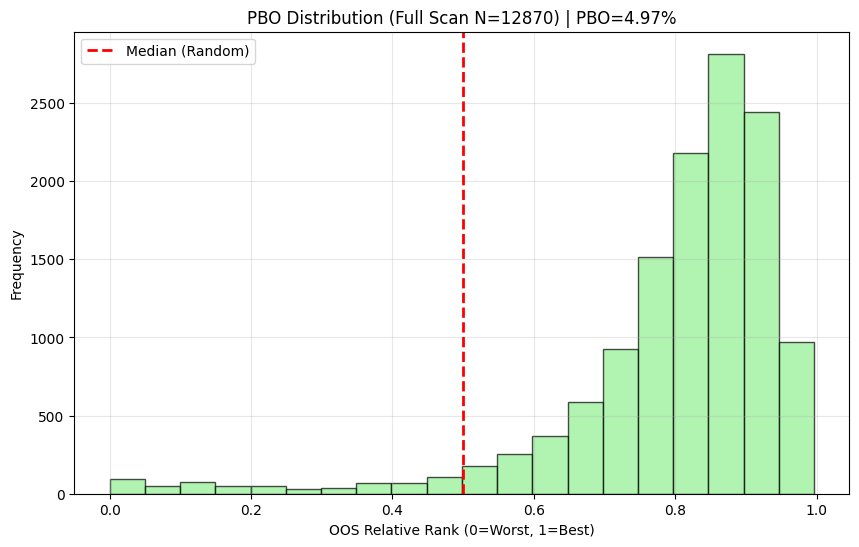

✅ KẾT LUẬN: Chiến lược VỮNG CHẮC (Robust).


In [16]:
# Cell 10: PBO Validator (Full Combinatorial Scan - Optimized)
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

class OverfittingTester:
    def __init__(self, prices_df, final_pairs):
        self.prices_df = prices_df
        self.pairs = final_pairs
        self.n_chunks = 16 # Chia dữ liệu thành 16 phần (S=16)

    def run_cscv(self):
        print(f"--- CHẠY FULL CSCV (NO SAMPLING) ---")

        # 1. Tính Ma trận Lợi nhuận (PnL Matrix) cho toàn bộ các cặp
        # Matrix kích thước (T x N), với T là số ngày, N là số cặp
        matrix_returns = []
        print(f"Đang tính PnL Matrix cho {len(self.pairs)} cặp...")

        valid_count = 0
        for idx, row in tqdm(self.pairs.iterrows(), total=len(self.pairs)):
            try:
                t1, t2 = row['Leg1'], row['Leg2']
                beta = row['Beta']

                # Tính Return hàng ngày
                ret_a = self.prices_df[t1].diff()
                ret_b = self.prices_df[t2].diff()

                # Chiến lược Mean Reversion cơ bản:
                # Mua Spread khi thấp, Bán khi cao -> PnL tỷ lệ nghịch với biến động Spread
                # (Đây là giả định chuẩn để test cấu trúc PBO mà không cần simulate từng lệnh)
                pair_pnl = -1 * (ret_a - beta * ret_b)

                # Fill NaN bằng 0 để không lỗi ma trận
                matrix_returns.append(pair_pnl.fillna(0).values)
                valid_count += 1
            except:
                continue

        # Chuyển list thành numpy array (Time x Strategies)
        M = np.array(matrix_returns).T
        T_len = M.shape[0]
        N_strats = M.shape[1]

        print(f"Matrix Shape: {M.shape} (Days x Strategies)")

        # 2. Tạo Tổ hợp (Combinations)
        # Chia dữ liệu thành 16 chunks
        chunk_size = T_len // self.n_chunks
        chunks = [range(i*chunk_size, (i+1)*chunk_size) for i in range(self.n_chunks)]

        # Lấy tất cả các cách chọn 8 chunks làm In-Sample (IS) từ 16 chunks
        # Số tổ hợp = 16C8 = 12,870
        combs = list(combinations(range(self.n_chunks), self.n_chunks // 2))
        print(f"Tổng số tổ hợp cần chạy: {len(combs)} (Full Scan)")

        # 3. Chạy Loop CSCV (Vectorized để tăng tốc)
        rank_logits = []

        print("Đang xử lý 12,870 tổ hợp...")
        for is_indices_set in tqdm(combs, desc="CSCV Progress"):
            # Tạo mask cho In-Sample (IS)
            is_mask = np.zeros(T_len, dtype=bool)
            for c_idx in is_indices_set:
                is_mask[chunks[c_idx]] = True

            # Mask cho Out-of-Sample (OOS) là phần còn lại
            oos_mask = ~is_mask

            # Tách dữ liệu ra 2 phần
            M_is = M[is_mask, :]
            M_oos = M[oos_mask, :]

            # --- TÍNH TOÁN TRÊN MA TRẬN (VECTORIZED) ---

            # A. Tính Sharpe Ratio trong IS (In-Sample)
            mean_is = np.mean(M_is, axis=0)
            std_is = np.std(M_is, axis=0)
            # Xử lý chia cho 0
            with np.errstate(divide='ignore', invalid='ignore'):
                sharpe_is = np.divide(mean_is, std_is, out=np.zeros_like(mean_is), where=std_is!=0)

            # Tìm chiến lược tốt nhất trong IS (Best Strategy Index)
            best_idx = np.argmax(sharpe_is)

            # B. Tính Sharpe Ratio trong OOS (Out-of-Sample)
            mean_oos = np.mean(M_oos, axis=0)
            std_oos = np.std(M_oos, axis=0)
            with np.errstate(divide='ignore', invalid='ignore'):
                sharpe_oos = np.divide(mean_oos, std_oos, out=np.zeros_like(mean_oos), where=std_oos!=0)

            # C. Xếp hạng chiến lược đó trong vùng OOS
            # argsort lần 1 trả về index, lần 2 trả về rank (thứ hạng)
            # Rank 0 là thấp nhất, N-1 là cao nhất
            ranks_oos = np.argsort(np.argsort(sharpe_oos))
            best_rank_oos = ranks_oos[best_idx]

            # Relative Rank (Chuẩn hóa về 0.0 -> 1.0)
            relative_rank = best_rank_oos / (N_strats - 1)
            rank_logits.append(relative_rank)

        # 4. Tính PBO (Tỷ lệ số lần Rank < 0.5)
        pbo_score = np.mean(np.array(rank_logits) < 0.5)

        return pbo_score, rank_logits

# --- THỰC THI ---
# Yêu cầu: Biến backtest_results phải có từ Cell 8
if 'backtest_results' in locals() and not backtest_results.empty:
    tester = OverfittingTester(prices_df, backtest_results)
    pbo, ranks = tester.run_cscv()

    print(f"\n========================================")
    print(f">>> FINAL PBO SCORE: {pbo:.4f} ({pbo*100:.2f}%)")
    print(f"========================================")

    # Vẽ biểu đồ phân phối
    plt.figure(figsize=(10, 6))
    plt.hist(ranks, bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
    plt.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Median (Random)')
    plt.title(f"PBO Distribution (Full Scan N={len(ranks)}) | PBO={pbo:.2%}")
    plt.xlabel("OOS Relative Rank (0=Worst, 1=Best)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Kết luận tự động
    if pbo < 0.2:
        print("✅ KẾT LUẬN: Chiến lược VỮNG CHẮC (Robust).")
    elif pbo < 0.4:
        print("⚠️ KẾT LUẬN: Chiến lược KHÁ (Decent). Cần đa dạng hóa danh mục.")
    else:
        print("❌ KẾT LUẬN: Chiến lược BỊ OVERFITTING CAO.")
else:
    print("❌ Lỗi: Chưa tìm thấy 'backtest_results'. Hãy chạy Cell 8 trước!")